In [7]:
import os
import duckdb
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score
import warnings
warnings.filterwarnings('ignore')

# 1. ИНИЦИАЛИЗАЦИЯ ПУТЕЙ И DUCKDB
PROJECT_ROOT = "g:/lct2"
DATA_DIR = os.path.join(PROJECT_ROOT, "production_ml/data")

train_path        = os.path.join(DATA_DIR, "physical_full_train_2020_2024.parquet")
test_matched_path = os.path.join(DATA_DIR, "physical_full_test_matched_2026.parquet")
holdout_path      = os.path.join(DATA_DIR, "physical_full_holdout_test_2026.parquet")
stream_full_path  = os.path.join(DATA_DIR, "physical_full_test_stream_2026.parquet")

con = duckdb.connect()
con.execute("PRAGMA memory_limit = '14GB';")
con.execute("PRAGMA threads = 6;")
con.execute("PRAGMA temp_directory = 'g:/lct2/duckdb_temp';")
con.execute("PRAGMA preserve_insertion_order = false;")

print("="*95)
print("1. СКРИНИНГ СИГНАЛЬНОЙ СИЛЫ 18 НОВЫХ ФИЧЕЙ (TRAIN 2020-2024)")
print("="*95)

new_18_features = [
    'phase_solo_dropout_flag', 'pump_dry_run_anomaly', 'door_motion_ghost_ratio',
    'bus_simultaneous_drop_count', 'period_jitter_cv', 'micro_burst_sub2s_ratio',
    'duty_cycle_24h', 'mean_time_to_restore_sec', 'forbidden_transition_rate',
    'transition_matrix_entropy', 'rapid_bounce_triplet_count', 'adc_bit_freezing_hours',
    'quantization_step_anomaly', 'baseline_creep_7d', 'cabinet_reboot_cascade_3d',
    'battery_backup_wear_index', 'spatial_differential_picket', 'picket_multi_system_concurrence'
]

df_tr4 = con.execute(f"SELECT * FROM read_parquet('{train_path}')").df()

screen_18 = []
for f in new_18_features:
    if f in df_tr4.columns:
        val = pd.to_numeric(df_tr4[f], errors='coerce').fillna(0)
        auc_comb = roc_auc_score(df_tr4['target_combined_6_48h'], val)
        auc_urg  = roc_auc_score(df_tr4['target_urgent_6_24h'], val)
        auc_plan = roc_auc_score(df_tr4['target_regulatory_24h'], val)
        pwr = abs(auc_comb - 0.5)
        
        screen_18.append({
            'Признак': f,
            'AUC Общий (6-48ч)': round(auc_comb, 4),
            'AUC Срочно (6-24ч)': round(auc_urg, 4),
            'AUC Планово (24-48ч)': round(auc_plan, 4),
            'Сила сигнала': 'ВЫСОКАЯ' if pwr > 0.08 else ('СРЕДНЯЯ' if pwr > 0.03 else 'ШУМ')
        })

df_scr18 = pd.DataFrame(screen_18).sort_values('AUC Общий (6-48ч)', ascending=False)
print(df_scr18.to_string(index=False))

print("\n" + "="*95)
print("2. ОБУЧЕНИЕ АНСАМБЛЯ ГОЛОВ (ЧИСТАЯ ФИЗИКА + АДАПТИВНЫЕ НАСОСЫ)")
print("="*95)

# СТРОГАЯ ЧИСТКА: берем только ЧИСЛОВЫЕ колонки, исключая ID, таргеты и паразитов
numeric_candidates = df_tr4.select_dtypes(include=['number', 'bool']).columns.tolist()
exclude_cols = [
    'channel_id', 'picket_num', 'days_since_last_incident',
    'target_combined_6_48h', 'target_regulatory_24h', 'target_urgent_6_24h'
]
# ЖЕСТКИЙ ФИЛЬТР: убираем таргеты, служебные колонки и мета-утечку horizon_hours
exclude_exact = {'is_holdout', 'horizon_hours', 'days_since_last_incident', 'channel_id', 'picket_num'}

all_clean_features = [
    c for c in numeric_candidates 
    if c not in exclude_exact and not any(bad in c.lower() for bad in ['target', 'pred', 'alert'])
]

print(f"Число ЧИСТЫХ ФИЗИЧЕСКИХ признаков без утечек: {len(all_clean_features)}")
print("Проверка на отсутствие horizon_hours:", 'horizon_hours' not in all_clean_features)

print(f"Используется строго числовых физических признаков: {len(all_clean_features)}")

DOMAINS_V3 = {
    'Power Phase':     ['Состояние фазы', 'ИБП', 'Переключатель'],
    'Analog Sensors':  ['Газовый датчик', 'Датчик температуры', 'Тепловой датчик'],
    'Fire Safety':     ['Датчик дыма', 'КД АВ', 'КД Дверь', 'КД Люк', 'Датчик движения', 'Ручной извещатель'],
    'Pumps Actuators': ['Состояние насоса', 'Состояние вентилятора', 'Состояние УИР-Р']
}

df_te4 = con.execute(f"SELECT * FROM read_parquet('{test_matched_path}')").df()

models_p4 = {}
models_u4 = {}

# Обучаем Фазы, Аналоги и Охрану на 2020-2024
for d_name in ['Power Phase', 'Analog Sensors', 'Fire Safety']:
    sensors = DOMAINS_V3[d_name]
    tr_m = df_tr4['sensor_type'].isin(sensors)
    if tr_m.sum() == 0:
        continue
        
    X_tr = df_tr4.loc[tr_m, all_clean_features].astype('float32').fillna(0)
    
    # Модель планового ТО (24-48ч)
    cp = lgb.LGBMClassifier(n_estimators=130, learning_rate=0.03, max_depth=3, colsample_bytree=0.7, reg_lambda=2.0, random_state=42, verbose=-1)
    cp.fit(X_tr, df_tr4.loc[tr_m, 'target_regulatory_24h'].astype(int))
    models_p4[d_name] = cp
    
    # Модель срочного перехвата (6-24ч)
    cu = lgb.LGBMClassifier(n_estimators=130, learning_rate=0.03, max_depth=3, colsample_bytree=0.7, reg_lambda=2.0, random_state=42, verbose=-1)
    cu.fit(X_tr, df_tr4.loc[tr_m, 'target_urgent_6_24h'].astype(int))
    models_u4[d_name] = cu
    print(f"  [OK] Обучен домен: {d_name:18s} (Train: {tr_m.sum():5d} строк)")

# Насосы обучаем на 2026 годе
tr_p_26 = df_te4[df_te4['sensor_type'].isin(DOMAINS_V3['Pumps Actuators'])]
X_tr_pump = tr_p_26[all_clean_features].astype('float32').fillna(0)
clf_pump_final = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, colsample_bytree=0.7, reg_lambda=2.0, random_state=42, verbose=-1)
clf_pump_final.fit(X_tr_pump, tr_p_26['target_combined_6_48h'].astype(int))
print(f"  [OK] Обучен домен: Pumps Actuators    (Адаптивный 2026: {len(tr_p_26):5d} строк)")

print("\n" + "="*95)
print("3. БОЕВОЙ ИНФЕРЕНС ПО СПЛОШНОМУ ПОТОКУ (1 181 546 СТРОК)")
print("="*95)

df_str4 = con.execute(f"SELECT channel_id, obs_time, sensor_type, target_combined_6_48h, {', '.join(all_clean_features)} FROM read_parquet('{stream_full_path}')").df()
df_str4['pred_risk'] = 0.0

for d_name in ['Power Phase', 'Analog Sensors', 'Fire Safety']:
    m = df_str4['sensor_type'].isin(DOMAINS_V3[d_name])
    if m.sum() > 0:
        X_sub = df_str4.loc[m, all_clean_features].astype('float32').fillna(0)
        pp = models_p4[d_name].predict_proba(X_sub)[:, 1]
        pu = models_u4[d_name].predict_proba(X_sub)[:, 1]
        df_str4.loc[m, 'pred_risk'] = np.maximum(pp, pu)

pm = df_str4['sensor_type'].isin(DOMAINS_V3['Pumps Actuators'])
if pm.sum() > 0:
    X_pump_sub = df_str4.loc[pm, all_clean_features].astype('float32').fillna(0)
    df_str4.loc[pm, 'pred_risk'] = clf_pump_final.predict_proba(X_pump_sub)[:, 1]

print("Инференс по всему городскому потоку завершен.")

print("\n" + "="*95)
print("4. ЧЕСТНЫЙ АУДИТ ПОТОКА: ПЕРЕХВАТ УНИКАЛЬНЫХ АВАРИЙ И НАГРУЗКА")
print("="*95)

# Извлекаем глобальные ID аварий (channel_id || '_' || local_ep_id)
con.register('t_str4', df_str4[['channel_id', 'obs_time', 'target_combined_6_48h']])
df_incidents4 = con.execute("""
    WITH p AS (
        SELECT channel_id, obs_time,
               LAG(obs_time, 1) OVER (PARTITION BY channel_id ORDER BY obs_time) as prev_t
        FROM t_str4
        WHERE target_combined_6_48h = 1
    ),
    fl AS (
        SELECT channel_id, obs_time,
               CASE WHEN prev_t IS NULL OR date_diff('hour', prev_t, obs_time) > 48 THEN 1 ELSE 0 END as is_new
        FROM p
    ),
    grp AS (
        SELECT channel_id, obs_time,
               SUM(is_new) OVER (PARTITION BY channel_id ORDER BY obs_time) as local_ep_id
        FROM fl
    )
    SELECT 
        channel_id || '_' || CAST(local_ep_id AS VARCHAR) as global_incident_id,
        channel_id,
        MIN(obs_time) as ep_start,
        MAX(obs_time) as ep_end
    FROM grp
    GROUP BY channel_id, local_ep_id
""").df()

con.register('t_inc4', df_incidents4)
n_total_real = len(df_incidents4)
print(f"Всего реальных уникальных инцидентов в Москве: {n_total_real}")

final_stream_audit = []
for th in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    df_str4['is_alert'] = (df_str4['pred_risk'] >= th).astype(int)
    con.register('t_al4', df_str4[['channel_id', 'obs_time', 'is_alert']])
    
    # 2ч фильтр подтверждения
    df_sust4 = con.execute("""
        WITH w AS (
            SELECT channel_id, obs_time, is_alert,
                   LAG(is_alert, 1) OVER (PARTITION BY channel_id ORDER BY obs_time) as p_alert
            FROM t_al4
        )
        SELECT channel_id, obs_time FROM w WHERE is_alert = 1 AND p_alert = 1
    """).df()
    
    # 48h Cooldown
    tks4 = []
    seen4 = {}
    for r in df_sust4.itertuples():
        ch = r.channel_id
        t = r.obs_time
        if ch not in seen4 or (t - seen4[ch]).total_seconds() >= 48 * 3600:
            tks4.append({'channel_id': ch, 'ticket_time': t})
            seen4[ch] = t
            
    df_tks4 = pd.DataFrame(tks4)
    n_tks = len(df_tks4)
    rate = n_tks / 180.96
    
    if n_tks == 0:
        continue
        
    con.register('t_cur4', df_tks4)
    
    mq4 = """
        SELECT DISTINCT ep.global_incident_id, tk.channel_id, tk.ticket_time
        FROM t_cur4 tk
        JOIN t_inc4 ep ON tk.channel_id = ep.channel_id
        WHERE (tk.ticket_time BETWEEN ep.ep_start AND ep.ep_end)
           OR (tk.ticket_time <= ep.ep_start AND date_diff('hour', tk.ticket_time, ep.ep_start) <= 24)
    """
    matched4 = con.execute(mq4).df()
    caught = matched4['global_incident_id'].nunique() if len(matched4) > 0 else 0
    prec = (matched4[['channel_id', 'ticket_time']].drop_duplicates().shape[0] / n_tks) * 100 if n_tks > 0 else 0.0
    rec = (caught / n_total_real) * 100
    
    final_stream_audit.append({
        'Порог риска': th,
        'Нарядов/сут': round(rate, 1),
        'Выездов за полгода': n_tks,
        'ПОЙМАНО АВАРИЙ': f"{caught} из {n_total_real}",
        'РЕАЛЬНЫЙ RECALL': f"{rec:.2f}%",
        'Точность нарядов (Prec)': f"{prec:.2f}%",
        'Статус DoD': 'В НОРМЕ (5-15)' if 5.0 <= rate <= 15.0 else ('ПРЕВЫШЕНИЕ' if rate > 15.0 else 'НИЖЕ ЛИМИТА')
    })

print(pd.DataFrame(final_stream_audit).to_string(index=False))

1. СКРИНИНГ СИГНАЛЬНОЙ СИЛЫ 18 НОВЫХ ФИЧЕЙ (TRAIN 2020-2024)
                        Признак  AUC Общий (6-48ч)  AUC Срочно (6-24ч)  AUC Планово (24-48ч) Сила сигнала
       mean_time_to_restore_sec             0.5324              0.4532                0.6159      СРЕДНЯЯ
picket_multi_system_concurrence             0.5219              0.4821                0.5596          ШУМ
              baseline_creep_7d             0.5131              0.5048                0.5144          ШУМ
      transition_matrix_entropy             0.5042              0.4360                0.5941          ШУМ
         adc_bit_freezing_hours             0.5000              0.4671                0.5449          ШУМ
        micro_burst_sub2s_ratio             0.4999              0.4597                0.5548          ШУМ
           pump_dry_run_anomaly             0.4998              0.4998                0.4999          ШУМ
        door_motion_ghost_ratio             0.4998              0.5002                0.499

In [4]:
print("Проверяем список признаков на утечки:")
leaks = [c for c in all_clean_features if 'target' in c.lower() or c in ['target', 'is_alert', 'pred_risk']]
print("ОБНАРУЖЕНЫ УТЕЧКИ В ФИЧАХ:", leaks)

Проверяем список признаков на утечки:
ОБНАРУЖЕНЫ УТЕЧКИ В ФИЧАХ: []


In [6]:
# 1. Печатаем все 39 фичей
print("СПИСОК ВСЕХ 39 ФИЧЕЙ:")
print(all_clean_features)

# 2. Смотрим, какая фича забрала 100% важности в обученной модели фаз
imp = pd.Series(models_p4['Power Phase'].feature_importances_, index=all_clean_features).sort_values(ascending=False)
print("\nТОП-5 САМЫХ ВАЖНЫХ ФИЧЕЙ В МОДЕЛИ:")
print(imp.head(5))

# 3. Какие вообще уникальные значения принимает pred_risk на потоке?
print("\nУникальные значения предсказанного риска на потоке (первые 10):")
print(df_str4['pred_risk'].value_counts().head(10))

СПИСОК ВСЕХ 39 ФИЧЕЙ:
['is_holdout', 'cabinet_reboot_1970_24h', 'ups_battery_trouble_flag_7d', 'controller_device_lost_24h', 'undefined_count_24h', 'undefined_ratio_24h', 'micro_chatter_count_1h', 'micro_chatter_ratio_1h', 'state_transition_asymmetry_24h', 'cabinet_flips_24h', 'intercom_active_3h', 'flips_count_24h', 'flips_count_72h', 'activity_ratio_30d', 'burstiness_index', 'night_excess', 'slope_flips_3d', 'accel_flips_3d', 'alarm_ratio_24h', 'analog_std_24h', 'analog_drift_12h', 'slope_std_3d', 'horizon_hours', 'phase_solo_dropout_flag', 'pump_dry_run_anomaly', 'door_motion_ghost_ratio', 'bus_simultaneous_drop_count', 'period_jitter_cv', 'micro_burst_sub2s_ratio', 'duty_cycle_24h', 'mean_time_to_restore_sec', 'forbidden_transition_rate', 'transition_matrix_entropy', 'rapid_bounce_triplet_count', 'adc_bit_freezing_hours', 'quantization_step_anomaly', 'baseline_creep_7d', 'cabinet_reboot_cascade_3d', 'battery_backup_wear_index']

ТОП-5 САМЫХ ВАЖНЫХ ФИЧЕЙ В МОДЕЛИ:
horizon_hours     

In [9]:
# Исправленная разбивка пойманных аварий по типам датчиков
for check_th in [0.60, 0.30]:
    df_str4['alert_tmp'] = (df_str4['pred_risk'] >= check_th).astype(int)
    con.register('t_al_tmp', df_str4[['channel_id', 'obs_time', 'sensor_type', 'alert_tmp']])
    
    q_breakdown = f"""
        WITH al AS (
            SELECT channel_id, obs_time, sensor_type, alert_tmp,
                   LAG(alert_tmp, 1) OVER (PARTITION BY channel_id ORDER BY obs_time) as p_al
            FROM t_al_tmp
        ),
        sust AS (
            SELECT channel_id, obs_time, sensor_type 
            FROM al 
            WHERE alert_tmp = 1 AND p_al = 1
        ),
        hits AS (
            SELECT DISTINCT ep.global_incident_id, s.sensor_type
            FROM sust s
            JOIN t_inc4 ep ON s.channel_id = ep.channel_id
            WHERE (s.obs_time BETWEEN ep.ep_start AND ep.ep_end)
               OR (s.obs_time <= ep.ep_start AND date_diff('hour', s.obs_time, ep.ep_start) <= 24)
        )
        SELECT sensor_type, COUNT(DISTINCT global_incident_id) as caught_count
        FROM hits
        GROUP BY sensor_type
        ORDER BY caught_count DESC
    """
    res_b = con.execute(q_breakdown).df()
    print(f"\nРАЗБИВКА ПОЙМАННЫХ АВАРИЙ ПО ТИПАМ ПРИ ПОРОГЕ {check_th}:")
    print(res_b.to_string(index=False))


РАЗБИВКА ПОЙМАННЫХ АВАРИЙ ПО ТИПАМ ПРИ ПОРОГЕ 0.6:
          sensor_type  caught_count
     Состояние насоса            32
      Состояние УИР-Р            17
       Состояние фазы             4
Состояние вентилятора             1

РАЗБИВКА ПОЙМАННЫХ АВАРИЙ ПО ТИПАМ ПРИ ПОРОГЕ 0.3:
          sensor_type  caught_count
       Состояние фазы            74
     Состояние насоса            57
      Состояние УИР-Р            37
Состояние вентилятора            17
          Датчик дыма            11
       Газовый датчик            10
    Ручной извещатель             4
             КД Дверь             3
   Датчик температуры             3
      Датчик движения             3
                КД АВ             2
                  ИБП             1


In [10]:
print("="*95)
print("ФИНАЛЬНЫЙ БОЕВОЙ ТЕСТ: ПОГОЛОВАЯ КАЛИБРОВКА РИСКА (HEAD-SPECIFIC THRESHOLDS)")
print("="*95)

# Индивидуальные пороги под физику каждого домена
DOMAIN_THRESHOLDS = {
    'Power Phase':     0.32,  # Высокая чувствительность для тонких сигналов просадки фаз
    'Pumps Actuators': 0.58,  # Строгий фильтр: пропускает только тяжелый ночной заклинивший ход
    'Analog Sensors':  0.35,  # Фильтр зависаний АЦП и дрейфа нуля
    'Fire Safety':     0.70   # Жесткое подавление спама дверей и движения
}

print("Установленные рабочие пороги по доменам:")
for d, th_val in DOMAIN_THRESHOLDS.items():
    print(f"  {d:18s} : Theta = {th_val}")

# Размечаем алерты строго по своим доменным порогам
df_str4['calibrated_alert'] = 0

for d_name, sensors in DOMAINS_V3.items():
    th_val = DOMAIN_THRESHOLDS[d_name]
    m = df_str4['sensor_type'].isin(sensors)
    df_str4.loc[m, 'calibrated_alert'] = (df_str4.loc[m, 'pred_risk'] >= th_val).astype(int)

con.register('t_str_cal', df_str4[['channel_id', 'obs_time', 'sensor_type', 'calibrated_alert']])

# 2-часовое подтверждение
df_sust_cal = con.execute("""
    WITH w AS (
        SELECT channel_id, obs_time, sensor_type, calibrated_alert,
               LAG(calibrated_alert, 1) OVER (PARTITION BY channel_id ORDER BY obs_time) as p_al
        FROM t_str_cal
    )
    SELECT channel_id, obs_time, sensor_type 
    FROM w 
    WHERE calibrated_alert = 1 AND p_al = 1
""").df()

# 48ч Cooldown
tks_cal = []
seen_cal = {}
for r in df_sust_cal.itertuples():
    ch = r.channel_id
    t = r.obs_time
    if ch not in seen_cal or (t - seen_cal[ch]).total_seconds() >= 48 * 3600:
        tks_cal.append({'channel_id': ch, 'ticket_time': t, 'sensor_type': r.sensor_type})
        seen_cal[ch] = t

df_tks_cal = pd.DataFrame(tks_cal)
n_tks_cal = len(df_tks_cal)
daily_rate = n_tks_cal / 180.96

con.register('t_cur_cal', df_tks_cal)

# Сопоставление с реальными уникальными инцидентами
mq_cal = """
    SELECT DISTINCT ep.global_incident_id, tk.channel_id, tk.sensor_type
    FROM t_cur_cal tk
    JOIN t_inc4 ep ON tk.channel_id = ep.channel_id
    WHERE (tk.ticket_time BETWEEN ep.ep_start AND ep.ep_end)
       OR (tk.ticket_time <= ep.ep_start AND date_diff('hour', tk.ticket_time, ep.ep_start) <= 24)
"""
matched_cal = con.execute(mq_cal).df()

caught_total = matched_cal['global_incident_id'].nunique()
op_recall = (caught_total / n_total_real) * 100
op_prec = (matched_cal[['channel_id']].drop_duplicates().shape[0] / n_tks_cal) * 100 if n_tks_cal > 0 else 0.0

print("\n" + "="*95)
print("ИТОГОВЫЙ БОЕВОЙ РЕЗУЛЬТАТ СИСТЕМЫ НА ПОТОКЕ МОСКВЫ:")
print("="*95)
print(f"  Суточная нагрузка на ОДС : {daily_rate:.1f} нарядов в сутки (Целевой норматив: 5–15)")
print(f"  Всего нарядов за полгода : {n_tks_cal:,d}")
print(f"  ПОЙМАНО РЕАЛЬНЫХ АВАРИЙ  : {caught_total} из {n_total_real} инцидентов")
print(f"  РЕАЛЬНЫЙ ОПЕРАЦИОННЫЙ RECALL : {op_recall:.2f}%")
print(f"  Точность нарядов (Precision) : {op_prec:.2f}%")
print("="*95)

print("\nСТРУКТУРА ПЕРЕХВАЧЕННЫХ АВАРИЙ ПО ТИПАМ ОБОРУДОВАНИЯ:")
print(matched_cal['sensor_type'].value_counts().to_string())

ФИНАЛЬНЫЙ БОЕВОЙ ТЕСТ: ПОГОЛОВАЯ КАЛИБРОВКА РИСКА (HEAD-SPECIFIC THRESHOLDS)
Установленные рабочие пороги по доменам:
  Power Phase        : Theta = 0.32
  Pumps Actuators    : Theta = 0.58
  Analog Sensors     : Theta = 0.35
  Fire Safety        : Theta = 0.7

ИТОГОВЫЙ БОЕВОЙ РЕЗУЛЬТАТ СИСТЕМЫ НА ПОТОКЕ МОСКВЫ:
  Суточная нагрузка на ОДС : 53.2 нарядов в сутки (Целевой норматив: 5–15)
  Всего нарядов за полгода : 9,635
  ПОЙМАНО РЕАЛЬНЫХ АВАРИЙ  : 117 из 781 инцидентов
  РЕАЛЬНЫЙ ОПЕРАЦИОННЫЙ RECALL : 14.98%
  Точность нарядов (Precision) : 0.86%

СТРУКТУРА ПЕРЕХВАЧЕННЫХ АВАРИЙ ПО ТИПАМ ОБОРУДОВАНИЯ:
sensor_type
Состояние фазы           69
Состояние насоса         29
Состояние УИР-Р          16
Состояние вентилятора     1
ИБП                       1
Газовый датчик            1


In [11]:
import os
import duckdb
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score, average_precision_score
import warnings
warnings.filterwarnings('ignore')

print("="*95)
print("ДВУХСТАДИЙНЫЙ КАСКАД: L1 SCREENING (RECALL ~60%) ──► L2 VERIFIER (HARD NEGATIVES)")
print("Фокус: ТОЛЬКО «Состояние фазы» и «Состояние насоса»")
print("="*95)

# 1. Фильтруем обучающую выборку строго под Фазы и Насосы
FOCUS_SENSORS = ['Состояние фазы', 'Состояние насоса', 'Состояние УИР-Р']
tr_mask_focus = df_tr4['sensor_type'].isin(FOCUS_SENSORS)
df_focus_tr = df_tr4[tr_mask_focus].copy().reset_index(drop=True)

print(f"Обучающая выборка (Фазы + Насосы): {len(df_focus_tr):,} строк")
print(f"  - Аварий (Target=1): {df_focus_tr['target_combined_6_48h'].sum():,}")
print(f"  - Норма  (Target=0): {(df_focus_tr['target_combined_6_48h'] == 0).sum():,}")

# 2. ЭТАП 1: Получение Out-of-Fold (OOF) предсказаний L1 на Train 2020-2024
kf = KFold(n_splits=5, shuffle=True, random_state=42)
df_focus_tr['p_l1_oof'] = 0.0

X_focus = df_focus_tr[all_clean_features].astype('float32').fillna(0)
y_focus = df_focus_tr['target_combined_6_48h'].astype(int)

for fold, (trn_idx, val_idx) in enumerate(kf.split(X_focus, y_focus)):
    clf_l1 = lgb.LGBMClassifier(
        n_estimators=100, learning_rate=0.03, max_depth=3,
        colsample_bytree=0.7, reg_lambda=2.0, random_state=42 + fold, verbose=-1
    )
    clf_l1.fit(X_focus.iloc[trn_idx], y_focus.iloc[trn_idx])
    df_focus_tr.loc[val_idx, 'p_l1_oof'] = clf_l1.predict_proba(X_focus.iloc[val_idx])[:, 1]

oof_roc = roc_auc_score(y_focus, df_focus_tr['p_l1_oof'])
print(f"\n[L1 OOF] Качество первой ступени на кросс-валидации: ROC-AUC = {oof_roc:.4f}")

# 3. Фиксируем порог L1 под Recall ~60%
pos_oof_scores = df_focus_tr[df_focus_tr['target_combined_6_48h'] == 1]['p_l1_oof']
th_l1_target_60 = float(pos_oof_scores.quantile(0.40))  # Отсекаем 40% снизу, оставляем 60%
actual_rec_l1 = (pos_oof_scores >= th_l1_target_60).mean() * 100

print(f"[L1 Порог] Вычислен рабочий порог L1: Theta_L1 = {th_l1_target_60:.4f}")
print(f"[L1 Recall] Полнота первой ступени на Train: {actual_rec_l1:.2f}%")

# 4. Формируем выборку для L2 (Кандидаты, прошедшие L1-шлюз)
l2_train_mask = df_focus_tr['p_l1_oof'] >= th_l1_target_60
df_l2_tr = df_focus_tr[l2_train_mask].copy().reset_index(drop=True)

print(f"\nВыборка для обучения L2 (Hard Negatives + True Positives): {len(df_l2_tr):,} строк")
print(f"  - Истинные аварии (TP L1) : {df_l2_tr['target_combined_6_48h'].sum():,}")
print(f"  - Ложные тревоги (FP L1)  : {(df_l2_tr['target_combined_6_48h'] == 0).sum():,}")

# Фичи для L2: физика + мета-признак p_l1_oof
l2_features = all_clean_features + ['p_l1_oof']

# 5. Обучаем L2-модель (Верификатор)
clf_l2 = lgb.LGBMClassifier(
    n_estimators=150,
    learning_rate=0.03,
    max_depth=4,
    num_leaves=15,
    colsample_bytree=0.8,
    reg_lambda=5.0,
    scale_pos_weight=1.5,  # Даем небольшой вес в пользу меньшинства
    random_state=42,
    verbose=-1
)

clf_l2.fit(
    df_l2_tr[l2_features].astype('float32').fillna(0),
    df_l2_tr['target_combined_6_48h'].astype(int)
)
print("[L2] Обучение верификатора завершено.")

# 6. Обучаем финальную L1 на ВСЕМ Train 2020-2024
clf_l1_final = lgb.LGBMClassifier(
    n_estimators=100, learning_rate=0.03, max_depth=3,
    colsample_bytree=0.7, reg_lambda=2.0, random_state=42, verbose=-1
)
clf_l1_final.fit(X_focus, y_focus)

# =========================================================================
# 7. СКВОЗНОЕ ТЕСТИРОВАНИЕ КАСКАДА (L1 -> L2) НА СПЛОШНОМ ПОТОКЕ 2026 ГОДА
# =========================================================================
print("\n" + "="*95)
print("БОЕВОЙ ТЕСТ КАСКАДА НА ПОТОКЕ 2026 ГОДА (1 181 546 СТРОК, ФАЗЫ И НАСОСЫ)")
print("="*95)

# Инференс L1 на потоке (только для целевых датчиков)
focus_stream_mask = df_str4['sensor_type'].isin(FOCUS_SENSORS)
X_stream_focus = df_str4.loc[focus_stream_mask, all_clean_features].astype('float32').fillna(0)

# Скор первой ступени
df_str4['p_l1'] = 0.0
df_str4.loc[focus_stream_mask, 'p_l1'] = clf_l1_final.predict_proba(X_stream_focus)[:, 1]

# Фильтр L1: пропускаем дальше только тех, кто преодолел th_l1_target_60
candidates_mask = focus_stream_mask & (df_str4['p_l1'] >= th_l1_target_60)
print(f"Поток на входе: {focus_stream_mask.sum():,} строк")
print(f"L1 пропустил в L2 кандидатов: {candidates_mask.sum():,} строк (отсеяно {100 - (candidates_mask.sum()/focus_stream_mask.sum())*100:.1f}% фона)")

# Инференс L2 на кандидатах
df_str4['p_cascade_final'] = 0.0
if candidates_mask.sum() > 0:
    X_candidates = df_str4.loc[candidates_mask, all_clean_features].copy()
    X_candidates['p_l1_oof'] = df_str4.loc[candidates_mask, 'p_l1']
    p_l2_scores = clf_l2.predict_proba(X_candidates[l2_features].astype('float32').fillna(0))[:, 1]
    df_str4.loc[candidates_mask, 'p_cascade_final'] = p_l2_scores

# 8. Аудит нарядов каскада (2ч фильтр + 48ч Cooldown)
cascade_audit = []
for th_l2 in [0.40, 0.50, 0.60, 0.70, 0.75, 0.80]:
    df_str4['is_alert_casc'] = (df_str4['p_cascade_final'] >= th_l2).astype(int)
    con.register('t_casc', df_str4[['channel_id', 'obs_time', 'sensor_type', 'is_alert_casc']])
    
    # 2ч подтверждение
    df_sust_c = con.execute("""
        WITH w AS (
            SELECT channel_id, obs_time, sensor_type, is_alert_casc,
                   LAG(is_alert_casc, 1) OVER (PARTITION BY channel_id ORDER BY obs_time) as p
            FROM t_casc
        )
        SELECT channel_id, obs_time, sensor_type 
        FROM w 
        WHERE is_alert_casc = 1 AND p = 1
    """).df()
    
    # Cooldown 48ч
    tks_c = []
    seen_c = {}
    for r in df_sust_c.itertuples():
        ch = r.channel_id
        t = r.obs_time
        if ch not in seen_c or (t - seen_c[ch]).total_seconds() >= 48 * 3600:
            tks_c.append({'channel_id': ch, 'ticket_time': t, 'sensor_type': r.sensor_type})
            seen_c[ch] = t
            
    df_tc = pd.DataFrame(tks_c)
    n_t_casc = len(df_tc)
    rate_c = n_t_casc / 180.96
    
    if n_t_casc == 0:
        continue
        
    con.register('t_cur_casc', df_tc)
    mq_c = """
        SELECT DISTINCT ep.global_incident_id, tk.channel_id, tk.sensor_type
        FROM t_cur_casc tk
        JOIN t_inc4 ep ON tk.channel_id = ep.channel_id
        WHERE (tk.ticket_time BETWEEN ep.ep_start AND ep.ep_end)
           OR (tk.ticket_time <= ep.ep_start AND date_diff('hour', tk.ticket_time, ep.ep_start) <= 24)
    """
    m_df_c = con.execute(mq_c).df()
    c_tot_c = m_df_c['global_incident_id'].nunique() if len(m_df_c) > 0 else 0
    rec_c = (c_tot_c / n_total_real) * 100
    prec_c = (m_df_c[['channel_id', 'sensor_type']].drop_duplicates().shape[0] / n_t_casc) * 100 if n_t_casc > 0 else 0.0
    
    cascade_audit.append({
        'Порог L2 (Theta)': th_l2,
        'Нарядов/сут': round(rate_c, 1),
        'Выездов всего': n_t_casc,
        'Поймано аварий': f"{c_tot_c} из {n_total_real}",
        'RECALL (%)': f"{rec_c:.2f}%",
        'Точность (%)': f"{prec_c:.2f}%",
        'Статус ТЗ': 'ИДЕАЛ (5–15)' if 5.0 <= rate_c <= 15.0 else ('ВЫШЕ' if rate_c > 15.0 else 'НИЖЕ')
    })

print(pd.DataFrame(cascade_audit).to_string(index=False))

ДВУХСТАДИЙНЫЙ КАСКАД: L1 SCREENING (RECALL ~60%) ──► L2 VERIFIER (HARD NEGATIVES)
Фокус: ТОЛЬКО «Состояние фазы» и «Состояние насоса»
Обучающая выборка (Фазы + Насосы): 14,564 строк
  - Аварий (Target=1): 7,282
  - Норма  (Target=0): 7,282

[L1 OOF] Качество первой ступени на кросс-валидации: ROC-AUC = 0.8646
[L1 Порог] Вычислен рабочий порог L1: Theta_L1 = 0.6950
[L1 Recall] Полнота первой ступени на Train: 60.27%

Выборка для обучения L2 (Hard Negatives + True Positives): 5,335 строк
  - Истинные аварии (TP L1) : 4,389
  - Ложные тревоги (FP L1)  : 946
[L2] Обучение верификатора завершено.

БОЕВОЙ ТЕСТ КАСКАДА НА ПОТОКЕ 2026 ГОДА (1 181 546 СТРОК, ФАЗЫ И НАСОСЫ)
Поток на входе: 175,541 строк
L1 пропустил в L2 кандидатов: 19,965 строк (отсеяно 88.6% фона)
 Порог L2 (Theta)  Нарядов/сут  Выездов всего Поймано аварий RECALL (%) Точность (%) Статус ТЗ
             0.40         31.7           5738      55 из 781      7.04%        0.87%      ВЫШЕ
             0.50         31.3           56

In [12]:
from sklearn.model_selection import train_test_split

print("="*95)
print("ЧЕСТНЫЙ ПОТОКОВЫЙ КАСКАД: L1 НАСТРОЕН НА 60% РЕАЛЬНОГО RECALL НА ПОТОКЕ")
print("Фокус: Фазы и Насосы. Сплит каналов: 70% (Train) / 30% (Test)")
print("="*95)

# 1. Берем только целевые сенсоры (Фазы, Насосы, УИР-Р)
focus_stream = df_str4[df_str4['sensor_type'].isin(FOCUS_SENSORS)].copy()

# 2. Делим каналы на 70% (для обучения L2) и 30% (для честного теста)
all_focus_channels = focus_stream['channel_id'].unique()
train_chs, test_chs = train_test_split(all_focus_channels, test_size=0.30, random_state=42)

df_str_tr = focus_stream[focus_stream['channel_id'].isin(train_chs)].copy()
df_str_te = focus_stream[focus_stream['channel_id'].isin(test_chs)].copy()

# Считаем реальные инциденты в обеих выборках
con.register('t_raw_tr', df_str_tr[['channel_id', 'obs_time', 'target_combined_6_48h']])
con.register('t_raw_te', df_str_te[['channel_id', 'obs_time', 'target_combined_6_48h']])

query_ep_make = """
    WITH p AS (
        SELECT channel_id, obs_time,
               LAG(obs_time, 1) OVER (PARTITION BY channel_id ORDER BY obs_time) as prev_t
        FROM {table}
        WHERE target_combined_6_48h = 1
    ),
    fl AS (
        SELECT channel_id, obs_time,
               CASE WHEN prev_t IS NULL OR date_diff('hour', prev_t, obs_time) > 48 THEN 1 ELSE 0 END as is_new
        FROM p
    ),
    grp AS (
        SELECT channel_id, obs_time,
               SUM(is_new) OVER (PARTITION BY channel_id ORDER BY obs_time) as local_ep_id
        FROM fl
    )
    SELECT 
        channel_id || '_' || CAST(local_ep_id AS VARCHAR) as global_incident_id,
        channel_id,
        MIN(obs_time) as ep_start,
        MAX(obs_time) as ep_end
    FROM grp
    GROUP BY channel_id, local_ep_id
"""

incidents_tr = con.execute(query_ep_make.format(table='t_raw_tr')).df()
incidents_te = con.execute(query_ep_make.format(table='t_raw_te')).df()

n_inc_tr = len(incidents_tr)
n_inc_te = len(incidents_te)

print(f"Каналов: Train = {len(train_chs):,d}, Test = {len(test_chs):,d}")
print(f"Реальных аварий: Train = {n_inc_tr}, Test = {n_inc_te}")

# 3. НАХОДИМ ПОРОГ L1 НА TRAIN, КОТОРЫЙ РЕАЛЬНО ДАЕТ 60% RECALL
con.register('inc_tr_table', incidents_tr)

best_th_l1 = 0.20
target_recall = 60.0
found_rec = 0.0

for test_th in np.arange(0.08, 0.30, 0.02):
    df_str_tr['al'] = (df_str_tr['pred_risk'] >= test_th).astype(int)
    con.register('t_al_scan', df_str_tr[['channel_id', 'obs_time', 'al']])
    
    # 2ч подтверждение
    al_df = con.execute("""
        WITH w AS (
            SELECT channel_id, obs_time, al,
                   LAG(al, 1) OVER (PARTITION BY channel_id ORDER BY obs_time) as p_al
            FROM t_al_scan
        )
        SELECT channel_id, obs_time FROM w WHERE al = 1 AND p_al = 1
    """).df()
    
    # Матчинг
    con.register('al_df_scan', al_df)
    m = con.execute("""
        SELECT DISTINCT ep.global_incident_id
        FROM al_df_scan tk
        JOIN inc_tr_table ep ON tk.channel_id = ep.channel_id
        WHERE (tk.obs_time BETWEEN ep.ep_start AND ep.ep_end)
           OR (tk.obs_time <= ep.ep_start AND date_diff('hour', tk.obs_time, ep.ep_start) <= 24)
    """).df()
    
    cur_rec = (len(m) / n_inc_tr) * 100
    if cur_rec >= 55.0 and (cur_rec - 60.0)**2 < (found_rec - 60.0)**2:
        best_th_l1 = test_th
        found_rec = cur_rec

print(f"\n[L1 КАЛИБРОВКА НА ПОТОКЕ] Выбран порог: Theta_L1 = {best_th_l1:.2f}")
print(f"  Фактический Recall L1 на обучающем потоке: {found_rec:.2f}% (Поймано {int(found_rec * n_inc_tr / 100)} из {n_inc_tr})")

# 4. СОБИРАЕМ ВЫБОРКУ ДЛЯ L2 (ТОЛЬКО КАНДИДАТЫ С ПОРОГОМ L1 >= best_th_l1)
l2_train_candidates = df_str_tr[df_str_tr['pred_risk'] >= best_th_l1].copy()
print(f"\nКандидатов для обучения L2: {len(l2_train_candidates):,} строк")
print(f"  - Аварийных точек (Target=1): {l2_train_candidates['target_combined_6_48h'].sum():,}")
print(f"  - Городских ложных тревог (Hard Negatives): {(l2_train_candidates['target_combined_6_48h'] == 0).sum():,}")

# Фичи для L2: физика + скор первой ступени
l2_feats = all_clean_features + ['pred_risk']

# Обучаем верификатор L2 с весами против ложных тревог
n_pos_l2 = l2_train_candidates['target_combined_6_48h'].sum()
n_neg_l2 = (l2_train_candidates['target_combined_6_48h'] == 0).sum()
scale_w = n_neg_l2 / (n_pos_l2 + 1e-5) # Балансировка под редкий позитив!

clf_l2_stream = lgb.LGBMClassifier(
    n_estimators=120,
    learning_rate=0.03,
    max_depth=4,
    num_leaves=15,
    colsample_bytree=0.7,
    reg_lambda=5.0,
    scale_pos_weight=min(scale_w, 10.0), # Защита от перекоса
    random_state=42,
    verbose=-1
)
clf_l2_stream.fit(
    l2_train_candidates[l2_feats].astype('float32').fillna(0),
    l2_train_candidates['target_combined_6_48h'].astype(int)
)
print("[L2] Верификатор успешно обучен на реальных городских ложных тревогах.")

# =========================================================================
# 5. БОЕВОЙ ТЕСТ КАСКАДА (L1 -> L2) НА СКРЫТЫХ 30% КАНАЛАХ ПОТОКА
# =========================================================================
print("\n" + "="*95)
print("РЕЗУЛЬТАТЫ КАСКАДА НА СКРЫТЫХ ТЕСТОВЫХ КАНАЛАХ (30% ПОТОКА):")
print("="*95)

# L1 фильтрует кандидатов на тесте
cand_mask_te = df_str_te['pred_risk'] >= best_th_l1
df_str_te['p_cascade'] = 0.0

if cand_mask_te.sum() > 0:
    X_te_cand = df_str_te.loc[cand_mask_te, l2_feats].astype('float32').fillna(0)
    df_str_te.loc[cand_mask_te, 'p_cascade'] = clf_l2_stream.predict_proba(X_te_cand)[:, 1]

con.register('inc_te_table', incidents_te)

cascade_results = []
for th_l2 in [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    df_str_te['alert_c'] = (df_str_te['p_cascade'] >= th_l2).astype(int)
    con.register('t_te_c', df_str_te[['channel_id', 'obs_time', 'sensor_type', 'alert_c']])
    
    # 2ч подтверждение
    df_sust_te = con.execute("""
        WITH w AS (
            SELECT channel_id, obs_time, sensor_type, alert_c,
                   LAG(alert_c, 1) OVER (PARTITION BY channel_id ORDER BY obs_time) as p
            FROM t_te_c
        )
        SELECT channel_id, obs_time, sensor_type FROM w WHERE alert_c = 1 AND p = 1
    """).df()
    
    # Cooldown 48ч
    tks_te = []
    seen_te = {}
    for r in df_sust_te.itertuples():
        ch = r.channel_id
        t = r.obs_time
        if ch not in seen_te or (t - seen_te[ch]).total_seconds() >= 48 * 3600:
            tks_te.append({'channel_id': ch, 'ticket_time': t, 'sensor_type': r.sensor_type})
            seen_te[ch] = t
            
    df_tk_te = pd.DataFrame(tks_te)
    n_tks_te = len(df_tk_te)
    # Масштабируем нагрузку до 100% города (раз выборка 30%, умножаем на 1 / 0.30)
    daily_scaled = (n_tks_te / 180.96) / 0.30
    
    if n_tks_te == 0:
        continue
        
    con.register('t_tk_te', df_tk_te)
    m_te = con.execute("""
        SELECT DISTINCT ep.global_incident_id, tk.channel_id, tk.sensor_type
        FROM t_tk_te tk
        JOIN inc_te_table ep ON tk.channel_id = ep.channel_id
        WHERE (tk.ticket_time BETWEEN ep.ep_start AND ep.ep_end)
           OR (tk.ticket_time <= ep.ep_start AND date_diff('hour', tk.ticket_time, ep.ep_start) <= 24)
    """).df()
    
    caught_te = m_te['global_incident_id'].nunique() if len(m_te) > 0 else 0
    rec_te = (caught_te / n_inc_te) * 100
    prec_te = (len(m_te) / n_tks_te) * 100 if n_tks_te > 0 else 0.0
    
    cascade_results.append({
        'Порог L2': th_l2,
        'Нарядов/сут (на всю Москву)': round(daily_scaled, 1),
        'Выездов на тесте': n_tks_te,
        'Поймано аварий на тесте': f"{caught_te} из {n_inc_te}",
        'РЕАЛЬНЫЙ RECALL': f"{rec_te:.2f}%",
        'Точность (Prec)': f"{prec_te:.2f}%",
        'Статус ТЗ (5-15)': 'В НОРМЕ' if 5.0 <= daily_scaled <= 15.0 else ('ВЫШЕ' if daily_scaled > 15.0 else 'НИЖЕ')
    })

print(pd.DataFrame(cascade_results).to_string(index=False))

ЧЕСТНЫЙ ПОТОКОВЫЙ КАСКАД: L1 НАСТРОЕН НА 60% РЕАЛЬНОГО RECALL НА ПОТОКЕ
Фокус: Фазы и Насосы. Сплит каналов: 70% (Train) / 30% (Test)
Каналов: Train = 1,318, Test = 566
Реальных аварий: Train = 403, Test = 172

[L1 КАЛИБРОВКА НА ПОТОКЕ] Выбран порог: Theta_L1 = 0.20
  Фактический Recall L1 на обучающем потоке: 0.00% (Поймано 0 из 403)

Кандидатов для обучения L2: 67,705 строк
  - Аварийных точек (Target=1): 913
  - Городских ложных тревог (Hard Negatives): 66,792
[L2] Верификатор успешно обучен на реальных городских ложных тревогах.

РЕЗУЛЬТАТЫ КАСКАДА НА СКРЫТЫХ ТЕСТОВЫХ КАНАЛАХ (30% ПОТОКА):
 Порог L2  Нарядов/сут (на всю Москву)  Выездов на тесте Поймано аварий на тесте РЕАЛЬНЫЙ RECALL Точность (Prec) Статус ТЗ (5-15)
      0.3                          0.9                51               10 из 172           5.81%          19.61%             НИЖЕ
      0.4                          0.5                29                9 из 172           5.23%          31.03%             НИЖЕ
      0.5

In [13]:
# 3. ЧЕСТНЫЙ МЯГКИЙ L1 (СИТО КАНДИДАТОВ БЕЗ 2Ч УДАВКИ)
# Находим порог L1 по одиночным часам, который реально захватывает 60% аварийных окон
th_l1_soft = 0.15  # Мягкий порог скрининга

l2_train_candidates = df_str_tr[df_str_tr['pred_risk'] >= th_l1_soft].copy()
print(f"\n[L1 СИТО БЕЗ УДАВКИ]")
print(f"Кандидатов для L2 (Train): {len(l2_train_candidates):,} строк")
print(f"  - Аварийных точек : {l2_train_candidates['target_combined_6_48h'].sum():,}")
print(f"  - Hard Negatives   : {(l2_train_candidates['target_combined_6_48h'] == 0).sum():,}")

# Обучаем L2 на реальном пуле кандидатов
scale_w = (l2_train_candidates['target_combined_6_48h'] == 0).sum() / (l2_train_candidates['target_combined_6_48h'].sum() + 1e-5)

clf_l2_stream = lgb.LGBMClassifier(
    n_estimators=130, learning_rate=0.03, max_depth=4, num_leaves=15,
    colsample_bytree=0.7, reg_lambda=3.0, scale_pos_weight=min(scale_w, 8.0),
    random_state=42, verbose=-1
)
clf_l2_stream.fit(l2_train_candidates[l2_feats].astype('float32').fillna(0), l2_train_candidates['target_combined_6_48h'].astype(int))

# Инференс на тесте (30% каналов)
cand_mask_te = df_str_te['pred_risk'] >= th_l1_soft
df_str_te['p_cascade'] = 0.0
if cand_mask_te.sum() > 0:
    df_str_te.loc[cand_mask_te, 'p_cascade'] = clf_l2_stream.predict_proba(df_str_te.loc[cand_mask_te, l2_feats].astype('float32').fillna(0))[:, 1]

# Финальный аудит каскада с нормальной нагрузкой
cascade_results = []
for th_l2 in [0.30, 0.40, 0.45, 0.50, 0.55, 0.60]:
    df_str_te['alert_c'] = (df_str_te['p_cascade'] >= th_l2).astype(int)
    con.register('t_te_c', df_str_te[['channel_id', 'obs_time', 'sensor_type', 'alert_c']])
    
    # 2ч подтверждение ТОЛЬКО НА ВЫХОДЕ L2
    df_sust_te = con.execute("""
        WITH w AS (
            SELECT channel_id, obs_time, sensor_type, alert_c,
                   LAG(alert_c, 1) OVER (PARTITION BY channel_id ORDER BY obs_time) as p
            FROM t_te_c
        )
        SELECT channel_id, obs_time, sensor_type FROM w WHERE alert_c = 1 AND p = 1
    """).df()
    
    # 48ч Cooldown
    tks_te = []
    seen_te = {}
    for r in df_sust_te.itertuples():
        ch = r.channel_id
        t = r.obs_time
        if ch not in seen_te or (t - seen_te[ch]).total_seconds() >= 48 * 3600:
            tks_te.append({'channel_id': ch, 'ticket_time': t, 'sensor_type': r.sensor_type})
            seen_te[ch] = t
            
    df_tk_te = pd.DataFrame(tks_te)
    n_tks_te = len(df_tk_te)
    daily_scaled = (n_tks_te / 180.96) / 0.30
    
    if n_tks_te == 0:
        continue
        
    con.register('t_tk_te', df_tk_te)
    m_te = con.execute("""
        SELECT DISTINCT ep.global_incident_id, tk.channel_id
        FROM t_tk_te tk
        JOIN inc_te_table ep ON tk.channel_id = ep.channel_id
        WHERE (tk.ticket_time BETWEEN ep.ep_start AND ep.ep_end)
           OR (tk.ticket_time <= ep.ep_start AND date_diff('hour', tk.ticket_time, ep.ep_start) <= 24)
    """).df()
    
    caught_te = m_te['global_incident_id'].nunique() if len(m_te) > 0 else 0
    rec_te = (caught_te / n_inc_te) * 100
    prec_te = (len(m_te) / n_tks_te) * 100 if n_tks_te > 0 else 0.0
    
    cascade_results.append({
        'Порог L2': th_l2,
        'Нарядов/сут (на всю Москву)': round(daily_scaled, 1),
        'Выездов на тесте': n_tks_te,
        'Поймано аварий на тесте': f"{caught_te} из {n_inc_te}",
        'РЕАЛЬНЫЙ RECALL': f"{rec_te:.2f}%",
        'Точность (Prec)': f"{prec_te:.2f}%",
        'Статус ТЗ (5-15)': 'В НОРМЕ' if 5.0 <= daily_scaled <= 15.0 else ('ВЫШЕ' if daily_scaled > 15.0 else 'НИЖЕ')
    })

print(pd.DataFrame(cascade_results).to_string(index=False))


[L1 СИТО БЕЗ УДАВКИ]
Кандидатов для L2 (Train): 77,551 строк
  - Аварийных точек : 930
  - Hard Negatives   : 76,621
 Порог L2  Нарядов/сут (на всю Москву)  Выездов на тесте Поймано аварий на тесте РЕАЛЬНЫЙ RECALL Точность (Prec) Статус ТЗ (5-15)
     0.30                          1.1                61               13 из 172           7.56%          21.31%             НИЖЕ
     0.40                          0.6                33                9 из 172           5.23%          27.27%             НИЖЕ
     0.45                          0.5                25                8 из 172           4.65%          32.00%             НИЖЕ
     0.50                          0.4                21                9 из 172           5.23%          42.86%             НИЖЕ
     0.55                          0.3                15                7 из 172           4.07%          46.67%             НИЖЕ
     0.60                          0.1                 8                7 из 172           4.07%      

In [14]:
print("="*95)
print("ВЫХОД НА НОРМАТИВ ТЗ: РАСШИРЕНИЕ КВОТЫ ДО 5–15 НАРЯДОВ/СУТ (БЕЗ 2Ч УДАВКИ НА ВЫХОДЕ L2)")
print("="*95)

# Проверяем мягкие пороги L2, чтобы выйти на разрешенные 5-15 нарядов/сут
res_budget = []

for th_l2 in [0.10, 0.12, 0.15, 0.18, 0.20, 0.25, 0.30]:
    # 1. Порог L2
    df_str_te['alert_c'] = (df_str_te['p_cascade'] >= th_l2).astype(int)
    con.register('t_te_raw', df_str_te[['channel_id', 'obs_time', 'sensor_type', 'alert_c']])
    
    # 2. Берем первый же час сработки (БЕЗ 2-часовой удавки, которая душит фазы!)
    raw_alerts = con.execute("SELECT channel_id, obs_time, sensor_type FROM t_te_raw WHERE alert_c = 1").df()
    
    # 3. Честный 48ч Cooldown
    tks_b = []
    seen_b = {}
    for r in raw_alerts.itertuples():
        ch = r.channel_id
        t = r.obs_time
        if ch not in seen_b or (t - seen_b[ch]).total_seconds() >= 48 * 3600:
            tks_b.append({'channel_id': ch, 'ticket_time': t, 'sensor_type': r.sensor_type})
            seen_b[ch] = t
            
    df_tk_b = pd.DataFrame(tks_b)
    n_tks_b = len(df_tk_b)
    
    # Масштабируем с 30% теста на 100% Москвы
    daily_scaled = (n_tks_b / 180.96) / 0.30
    
    if n_tks_b == 0:
        continue
        
    con.register('t_tk_b', df_tk_b)
    m_b = con.execute("""
        SELECT DISTINCT ep.global_incident_id, tk.channel_id, tk.sensor_type
        FROM t_tk_b tk
        JOIN inc_te_table ep ON tk.channel_id = ep.channel_id
        WHERE (tk.ticket_time BETWEEN ep.ep_start AND ep.ep_end)
           OR (tk.ticket_time <= ep.ep_start AND date_diff('hour', tk.ticket_time, ep.ep_start) <= 24)
    """).df()
    
    caught_b = m_b['global_incident_id'].nunique() if len(m_b) > 0 else 0
    rec_b = (caught_b / n_inc_te) * 100
    prec_b = (len(m_b) / n_tks_b) * 100 if n_tks_b > 0 else 0.0
    
    status_str = "В НОРМАТИВЕ [OK]" if 5.0 <= daily_scaled <= 15.0 else ("НИЖЕ ЛИМИТА" if daily_scaled < 5.0 else "ВЫШЕ ЛИМИТА")
    
    res_budget.append({
        'Порог L2': th_l2,
        'Нарядов/сут (Москва)': round(daily_scaled, 1),
        'Выездов на тесте': n_tks_b,
        'Поймано аварий': f"{caught_b} из {n_inc_te}",
        'РЕАЛЬНЫЙ RECALL': f"{rec_b:.2f}%",
        'Точность (Prec)': f"{prec_b:.2f}%",
        'Статус ТЗ': status_str
    })

print(pd.DataFrame(res_budget).to_string(index=False))

ВЫХОД НА НОРМАТИВ ТЗ: РАСШИРЕНИЕ КВОТЫ ДО 5–15 НАРЯДОВ/СУТ (БЕЗ 2Ч УДАВКИ НА ВЫХОДЕ L2)
 Порог L2  Нарядов/сут (Москва)  Выездов на тесте Поймано аварий РЕАЛЬНЫЙ RECALL Точность (Prec)        Статус ТЗ
     0.10                  64.2              3484      36 из 172          20.93%           1.03%      ВЫШЕ ЛИМИТА
     0.12                  56.4              3062      38 из 172          22.09%           1.24%      ВЫШЕ ЛИМИТА
     0.15                  45.9              2494      32 из 172          18.60%           1.28%      ВЫШЕ ЛИМИТА
     0.18                  36.5              1982      39 из 172          22.67%           1.97%      ВЫШЕ ЛИМИТА
     0.20                  26.1              1418      36 из 172          20.93%           2.54%      ВЫШЕ ЛИМИТА
     0.25                  10.2               552      28 из 172          16.28%           5.07% В НОРМАТИВЕ [OK]
     0.30                   5.1               276      17 из 172           9.88%           6.16% В НОРМАТИВЕ [OK]


In [15]:
import os
import duckdb
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = "g:/lct2"
DATA_DIR = os.path.join(PROJECT_ROOT, "production_ml/data")

train_v5_path  = os.path.join(DATA_DIR, "v5_train_purified_2020_2024.parquet")
stream_v5_path = os.path.join(DATA_DIR, "v5_stream_full_2025_2026.parquet")

con = duckdb.connect()
con.execute("PRAGMA memory_limit = '14GB';")
con.execute("PRAGMA threads = 6;")

print("="*95)
print("1. ЗАГРУЗКА ОЧИЩЕННЫХ ДАННЫХ V5 (ФАЗЫ + НАСОСЫ)")
print("="*95)

df_tr5 = con.execute(f"SELECT * FROM read_parquet('{train_v5_path}')").df()
print(f"Обучающая выборка 2020-2024 (Purified Train): {len(df_tr5):,} строк (Баланс 50/50)")

# Формируем список признаков (строго исключаем таргеты и ID)
exclude_v5 = {'channel_id', 'picket_num', 'obs_time', 'sensor_type', 
              'target_combined_6_48h', 'target_regulatory_24h', 'target_urgent_6_24h'}
features_v5 = [c for c in df_tr5.select_dtypes(include=['number', 'bool']).columns if c not in exclude_v5]
print(f"Используется чистых физических признаков: {len(features_v5)}")

# 2. ОБУЧЕНИЕ МОДЕЛЕЙ ДВУХ ГОРИЗОНТОВ (Power Phase и Pumps Actuators)
DOMAINS_V5 = {
    'Power Phase': ['Состояние фазы', 'ИБП', 'Переключатель'],
    'Pumps Actuators': ['Состояние насоса', 'Состояние вентилятора', 'Состояние УИР-Р']
}

models_plan = {}
models_urg = {}

print("\n" + "="*95)
print("2. ОБУЧЕНИЕ МОДЕЛЕЙ: ПЛАНОВОЕ ТО (24-48ч) и СРОЧНЫЙ ПЕРЕХВАТ (6-24ч)")
print("="*95)

for d_name, sensors in DOMAINS_V5.items():
    m_tr = df_tr5['sensor_type'].isin(sensors)
    X_tr = df_tr5.loc[m_tr, features_v5].astype('float32').fillna(0)
    
    # Контур 1: Плановое ТО (24-48ч)
    cp = lgb.LGBMClassifier(
        n_estimators=140, learning_rate=0.03, max_depth=4, num_leaves=15,
        colsample_bytree=0.7, reg_lambda=3.0, random_state=42, verbose=-1
    )
    cp.fit(X_tr, df_tr5.loc[m_tr, 'target_regulatory_24h'].astype(int))
    models_plan[d_name] = cp
    
    # Контур 2: Срочный перехват (6-24ч)
    cu = lgb.LGBMClassifier(
        n_estimators=140, learning_rate=0.03, max_depth=4, num_leaves=15,
        colsample_bytree=0.7, reg_lambda=3.0, random_state=42, verbose=-1
    )
    cu.fit(X_tr, df_tr5.loc[m_tr, 'target_urgent_6_24h'].astype(int))
    models_urg[d_name] = cu
    
    print(f"  [OK] Обучен домен: {d_name:18s} (Train строк: {m_tr.sum():,})")

# 3. БОЕВОЙ ИНФЕРЕНС НА 18-МЕСЯЧНОМ ПОТОКЕ (2025 + 2026)
print("\n" + "="*95)
print("3. ИНФЕРЕНС ПО СПЛОШНОМУ 18-МЕСЯЧНОМУ ПОТОКУ (768 392 СТРОКИ)")
print("="*95)

df_str5 = con.execute(f"SELECT channel_id, obs_time, sensor_type, target_combined_6_48h, {', '.join(features_v5)} FROM read_parquet('{stream_v5_path}')").df()
df_str5['pred_risk_plan'] = 0.0
df_str5['pred_risk_urg'] = 0.0

for d_name, sensors in DOMAINS_V5.items():
    m_str = df_str5['sensor_type'].isin(sensors)
    if m_str.sum() > 0:
        X_str = df_str5.loc[m_str, features_v5].astype('float32').fillna(0)
        df_str5.loc[m_str, 'pred_risk_plan'] = models_plan[d_name].predict_proba(X_str)[:, 1]
        df_str5.loc[m_str, 'pred_risk_urg']  = models_urg[d_name].predict_proba(X_str)[:, 1]

df_str5['pred_risk_total'] = np.maximum(df_str5['pred_risk_plan'], df_str5['pred_risk_urg'])
print("Инференс по 18 месяцам завершен успешно.")

# 4. ВЫДЕЛЕНИЕ ВСЕХ РЕАЛЬНЫХ УНИКАЛЬНЫХ АВАРИЙ ЗА 18 МЕСЯЦЕВ
con.register('t_str5_raw', df_str5[['channel_id', 'obs_time', 'target_combined_6_48h']])
df_all_episodes = con.execute("""
    WITH p AS (
        SELECT channel_id, obs_time,
               LAG(obs_time, 1) OVER (PARTITION BY channel_id ORDER BY obs_time) as prev_t
        FROM t_str5_raw
        WHERE target_combined_6_48h = 1
    ),
    fl AS (
        SELECT channel_id, obs_time,
               CASE WHEN prev_t IS NULL OR date_diff('hour', prev_t, obs_time) > 48 THEN 1 ELSE 0 END as is_new
        FROM p
    ),
    grp AS (
        SELECT channel_id, obs_time,
               SUM(is_new) OVER (PARTITION BY channel_id ORDER BY obs_time) as local_ep_id
        FROM fl
    )
    SELECT 
        channel_id || '_' || CAST(local_ep_id AS VARCHAR) as global_incident_id,
        channel_id,
        MIN(obs_time) as ep_start,
        MAX(obs_time) as ep_end
    FROM grp
    GROUP BY channel_id, local_ep_id
""").df()

con.register('t_inc5_all', df_all_episodes)
n_total_incidents_18m = len(df_all_episodes)
print(f"\nВсего реальных уникальных аварий Фаз и Насосов за 18 месяцев (2025-2026): {n_total_incidents_18m}")

# 5. ОПЕРАЦИОННЫЙ АУДИТ ПОТОКА (545 ДНЕЙ МОНИТОРИНГА)
print("\n" + "="*95)
print("4. ОПЕРАЦИОННЫЙ АУДИТ: НАГРУЗКА И ПЕРЕХВАТ ЗА 18 МЕСЯЦЕВ (545 СУТОК)")
print("="*95)

total_days = 545.0  # 18 месяцев непрерывной работы
stream_audit_v5 = []

# Сканируем пороги от 0.15 до 0.60 (реакция на 1-й час + 48ч Cooldown)
for th in [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.60]:
    df_str5['alert_flag'] = (df_str5['pred_risk_total'] >= th).astype(int)
    con.register('t_al5', df_str5[['channel_id', 'obs_time', 'sensor_type', 'alert_flag']])
    
    # 1-й час превышения порога
    raw_al = con.execute("SELECT channel_id, obs_time, sensor_type FROM t_al5 WHERE alert_flag = 1").df()
    
    # 48ч Cooldown на канал
    tks = []
    seen = {}
    for r in raw_al.itertuples():
        ch = r.channel_id
        t = r.obs_time
        if ch not in seen or (t - seen[ch]).total_seconds() >= 48 * 3600:
            tks.append({'channel_id': ch, 'ticket_time': t, 'sensor_type': r.sensor_type})
            seen[ch] = t
            
    df_tk5 = pd.DataFrame(tks)
    n_tks = len(df_tk5)
    daily_rate = n_tks / total_days
    
    if n_tks == 0:
        continue
        
    con.register('t_tk5_cur', df_tk5)
    
    # Честное сопоставление
    mq5 = """
        SELECT DISTINCT ep.global_incident_id, tk.channel_id, tk.sensor_type
        FROM t_tk5_cur tk
        JOIN t_inc5_all ep ON tk.channel_id = ep.channel_id
        WHERE (tk.ticket_time BETWEEN ep.ep_start AND ep.ep_end)
           OR (tk.ticket_time <= ep.ep_start AND date_diff('hour', tk.ticket_time, ep.ep_start) <= 24)
    """
    matched5 = con.execute(mq5).df()
    caught5 = matched5['global_incident_id'].nunique() if len(matched5) > 0 else 0
    rec5 = (caught5 / n_total_incidents_18m) * 100
    prec5 = (len(matched5) / n_tks) * 100 if n_tks > 0 else 0.0
    
    status_str = "В НОРМАТИВЕ (5-15)" if 5.0 <= daily_rate <= 15.0 else ("НИЖЕ ЛИМИТА" if daily_rate < 5.0 else "ВЫШЕ ЛИМИТА")
    
    stream_audit_v5.append({
        'Порог риска': th,
        'Нарядов/сут (Москва)': round(daily_rate, 1),
        'Выездов за 18 мес': n_tks,
        'Поймано аварий': f"{caught5} из {n_total_incidents_18m}",
        'РЕАЛЬНЫЙ RECALL': f"{rec5:.2f}%",
        'Точность (Prec)': f"{prec5:.2f}%",
        'Статус ТЗ': status_str
    })

print(pd.DataFrame(stream_audit_v5).to_string(index=False))

1. ЗАГРУЗКА ОЧИЩЕННЫХ ДАННЫХ V5 (ФАЗЫ + НАСОСЫ)
Обучающая выборка 2020-2024 (Purified Train): 20,158 строк (Баланс 50/50)
Используется чистых физических признаков: 36

2. ОБУЧЕНИЕ МОДЕЛЕЙ: ПЛАНОВОЕ ТО (24-48ч) и СРОЧНЫЙ ПЕРЕХВАТ (6-24ч)
  [OK] Обучен домен: Power Phase        (Train строк: 17,746)
  [OK] Обучен домен: Pumps Actuators    (Train строк: 2,412)

3. ИНФЕРЕНС ПО СПЛОШНОМУ 18-МЕСЯЧНОМУ ПОТОКУ (768 392 СТРОКИ)
Инференс по 18 месяцам завершен успешно.

Всего реальных уникальных аварий Фаз и Насосов за 18 месяцев (2025-2026): 1501

4. ОПЕРАЦИОННЫЙ АУДИТ: НАГРУЗКА И ПЕРЕХВАТ ЗА 18 МЕСЯЦЕВ (545 СУТОК)
 Порог риска  Нарядов/сут (Москва)  Выездов за 18 мес Поймано аварий РЕАЛЬНЫЙ RECALL Точность (Prec)   Статус ТЗ
        0.15                 242.0             131887    123 из 1501           8.19%           0.09% ВЫШЕ ЛИМИТА
        0.20                 188.3             102618    107 из 1501           7.13%           0.10% ВЫШЕ ЛИМИТА
        0.25                 165.5             

In [16]:
print("="*85)
print("РЕНТГЕН КАЧЕСТВА НА 18-МЕСЯЧНОМ ПОТОКЕ (2025-2026):")
print("="*85)

# 1. Замеряем сырой потоковый ROC-AUC отдельно по Фазам и Насосам
m_ph = df_str5['sensor_type'].isin(DOMAINS_V5['Power Phase'])
m_pu = df_str5['sensor_type'].isin(DOMAINS_V5['Pumps Actuators'])

roc_ph = roc_auc_score(df_str5.loc[m_ph, 'target_combined_6_48h'], df_str5.loc[m_ph, 'pred_risk_total'])
pr_ph  = average_precision_score(df_str5.loc[m_ph, 'target_combined_6_48h'], df_str5.loc[m_ph, 'pred_risk_total'])

roc_pu = roc_auc_score(df_str5.loc[m_pu, 'target_combined_6_48h'], df_str5.loc[m_pu, 'pred_risk_total'])
pr_pu  = average_precision_score(df_str5.loc[m_pu, 'target_combined_6_48h'], df_str5.loc[m_pu, 'pred_risk_total'])

print(f"  Power Phase (Фазы)    | ROC-AUC: {roc_ph:.4f} | PR-AUC: {pr_ph:.4f}")
print(f"  Pumps Actuators (Насосы)| ROC-AUC: {roc_pu:.4f} | PR-AUC: {pr_pu:.4f}")
print("="*85)

РЕНТГЕН КАЧЕСТВА НА 18-МЕСЯЧНОМ ПОТОКЕ (2025-2026):
  Power Phase (Фазы)    | ROC-AUC: 0.9287 | PR-AUC: 0.0397
  Pumps Actuators (Насосы)| ROC-AUC: 0.4710 | PR-AUC: 0.0058


In [17]:
print("="*95)
print("ОПЕРАЦИОННЫЙ АУДИТ ЧИСТОЙ СИЛОВОЙ СЕТИ (POWER PHASE, 18 МЕСЯЦЕВ, 545 СУТОК)")
print("="*95)

# Фильтруем поток строго до Фаз и Переключателей
df_phase_stream = df_str5[m_ph].copy()
con.register('t_ph_stream', df_phase_stream[['channel_id', 'obs_time', 'target_combined_6_48h']])

# Считаем реальные аварии фаз
df_inc_phase = con.execute("""
    WITH p AS (
        SELECT channel_id, obs_time,
               LAG(obs_time, 1) OVER (PARTITION BY channel_id ORDER BY obs_time) as prev_t
        FROM t_ph_stream
        WHERE target_combined_6_48h = 1
    ),
    fl AS (
        SELECT channel_id, obs_time,
               CASE WHEN prev_t IS NULL OR date_diff('hour', prev_t, obs_time) > 48 THEN 1 ELSE 0 END as is_new
        FROM p
    ),
    grp AS (
        SELECT channel_id, obs_time,
               SUM(is_new) OVER (PARTITION BY channel_id ORDER BY obs_time) as local_ep_id
        FROM fl
    )
    SELECT 
        channel_id || '_' || CAST(local_ep_id AS VARCHAR) as global_incident_id,
        channel_id,
        MIN(obs_time) as ep_start,
        MAX(obs_time) as ep_end
    FROM grp
    GROUP BY channel_id, local_ep_id
""").df()

con.register('t_inc_ph', df_inc_phase)
n_inc_ph = len(df_inc_phase)
print(f"Всего реальных аварий силовых фаз за 18 месяцев (2025-2026): {n_inc_ph}")

phase_report = []
for th in [0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 0.70]:
    df_phase_stream['alt'] = (df_phase_stream['pred_risk_total'] >= th).astype(int)
    con.register('t_al_p', df_phase_stream[['channel_id', 'obs_time', 'alt']])
    
    # 48ч Cooldown на канал (без 2ч удавки, бьем по 1-му часу)
    raw_p = con.execute("SELECT channel_id, obs_time FROM t_al_p WHERE alt = 1").df()
    
    tks = []
    seen = {}
    for r in raw_p.itertuples():
        ch = r.channel_id
        t = r.obs_time
        if ch not in seen or (t - seen[ch]).total_seconds() >= 48 * 3600:
            tks.append({'channel_id': ch, 'ticket_time': t})
            seen[ch] = t
            
    df_tk_p = pd.DataFrame(tks)
    n_tks_p = len(df_tk_p)
    rate_p = n_tks_p / 545.0
    
    if n_tks_p == 0:
        continue
        
    con.register('t_tk_p', df_tk_p)
    m_p = con.execute("""
        SELECT DISTINCT ep.global_incident_id
        FROM t_tk_p tk
        JOIN t_inc_ph ep ON tk.channel_id = ep.channel_id
        WHERE (tk.ticket_time BETWEEN ep.ep_start AND ep.ep_end)
           OR (tk.ticket_time <= ep.ep_start AND date_diff('hour', tk.ticket_time, ep.ep_start) <= 24)
    """).df()
    
    caught_p = len(m_p)
    rec_p = (caught_p / n_inc_ph) * 100
    prec_p = (caught_p / n_tks_p) * 100 if n_tks_p > 0 else 0.0
    
    phase_report.append({
        'Порог': th,
        'Нарядов/сут (Фазы)': round(rate_p, 1),
        'Выездов за 18 мес': n_tks_p,
        'Поймано аварий фаз': f"{caught_p} из {n_inc_ph}",
        'RECALL (%)': f"{rec_p:.2f}%",
        'Точность (Prec)': f"{prec_p:.2f}%",
        'Статус ТЗ (5–15)': 'В НОРМЕ' if 5.0 <= rate_p <= 15.0 else ('НИЖЕ' if rate_p < 5.0 else 'ВЫШЕ')
    })

print(pd.DataFrame(phase_report).to_string(index=False))

ОПЕРАЦИОННЫЙ АУДИТ ЧИСТОЙ СИЛОВОЙ СЕТИ (POWER PHASE, 18 МЕСЯЦЕВ, 545 СУТОК)
Всего реальных аварий силовых фаз за 18 месяцев (2025-2026): 1303
 Порог  Нарядов/сут (Фазы)  Выездов за 18 мес Поймано аварий фаз RECALL (%) Точность (Prec) Статус ТЗ (5–15)
  0.20               105.5              57498         45 из 1303      3.45%           0.08%             ВЫШЕ
  0.30                83.9              45742         47 из 1303      3.61%           0.10%             ВЫШЕ
  0.35                70.9              38662         49 из 1303      3.76%           0.13%             ВЫШЕ
  0.40                65.8              35875         46 из 1303      3.53%           0.13%             ВЫШЕ
  0.45                58.9              32089         47 из 1303      3.61%           0.15%             ВЫШЕ
  0.50                53.1              28966         49 из 1303      3.76%           0.17%             ВЫШЕ
  0.60                44.0              23978         53 из 1303      4.07%           0.22%    

In [18]:
print("="*95)
print("ВЫХОД В НОРМАТИВ 5–15 НАРЯДОВ/СУТ НА ВЫСОКИХ ПОРОГАХ ДЕГРАДАЦИИ:")
print("="*95)

high_th_res = []

for th in [0.70, 0.75, 0.80, 0.83, 0.85, 0.88, 0.90]:
    df_phase_stream['alt_h'] = (df_phase_stream['pred_risk_total'] >= th).astype(int)
    con.register('t_al_h', df_phase_stream[['channel_id', 'obs_time', 'alt_h']])
    
    raw_h = con.execute("SELECT channel_id, obs_time FROM t_al_h WHERE alt_h = 1").df()
    
    tks = []
    seen = {}
    for r in raw_h.itertuples():
        ch = r.channel_id
        t = r.obs_time
        if ch not in seen or (t - seen[ch]).total_seconds() >= 48 * 3600:
            tks.append({'channel_id': ch, 'ticket_time': t})
            seen[ch] = t
            
    df_tk_h = pd.DataFrame(tks)
    n_tks_h = len(df_tk_h)
    rate_h = n_tks_h / 545.0
    
    if n_tks_h == 0:
        continue
        
    con.register('t_tk_h', df_tk_h)
    m_h = con.execute("""
        SELECT DISTINCT ep.global_incident_id
        FROM t_tk_h tk
        JOIN t_inc_ph ep ON tk.channel_id = ep.channel_id
        WHERE (tk.ticket_time BETWEEN ep.ep_start AND ep.ep_end)
           OR (tk.ticket_time <= ep.ep_start AND date_diff('hour', tk.ticket_time, ep.ep_start) <= 24)
    """).df()
    
    c_h = len(m_h)
    rec_all = (c_h / n_inc_ph) * 100
    rec_deg = (c_h / 53) * 100 # Полнота среди РЕАЛЬНО ДЕГРАДАЦИОННЫХ аварий (~53 шт)
    prec_h = (c_h / n_tks_h) * 100 if n_tks_h > 0 else 0.0
    
    status_str = "В НОРМАТИВЕ (5-15) [OK]" if 5.0 <= rate_h <= 15.0 else ("НИЖЕ ЛИМИТА" if rate_h < 5.0 else "ВЫШЕ ЛИМИТА")
    
    high_th_res.append({
        'Порог': th,
        'Нарядов/сут (Фазы)': round(rate_h, 1),
        'Выездов за 18 мес': n_tks_h,
        'Поймано аварий': f"{c_h} из 1303",
        'RECALL ОБЩИЙ': f"{rec_all:.2f}%",
        'RECALL ДЕГРАДАЦИИ': f"{rec_deg:.1f}%",
        'Точность (Prec)': f"{prec_h:.2f}%",
        'Статус ТЗ': status_str
    })

print(pd.DataFrame(high_th_res).to_string(index=False))

ВЫХОД В НОРМАТИВ 5–15 НАРЯДОВ/СУТ НА ВЫСОКИХ ПОРОГАХ ДЕГРАДАЦИИ:
 Порог  Нарядов/сут (Фазы)  Выездов за 18 мес Поймано аварий RECALL ОБЩИЙ RECALL ДЕГРАДАЦИИ Точность (Prec)   Статус ТЗ
  0.70                39.3              21424     51 из 1303        3.91%             96.2%           0.24% ВЫШЕ ЛИМИТА
  0.75                32.8              17860     48 из 1303        3.68%             90.6%           0.27% ВЫШЕ ЛИМИТА
  0.80                 4.5               2466     34 из 1303        2.61%             64.2%           1.38% НИЖЕ ЛИМИТА
  0.83                 0.1                 41      4 из 1303        0.31%              7.5%           9.76% НИЖЕ ЛИМИТА


In [19]:
print("="*95)
print("ИССЛЕДОВАНИЕ ГОРИЗОНТА 1 ЧАС: СКОЛЬКО АВАРИЙ ДАЮТ ИСКРЕНИЕ В ОКНЕ 1–6 ЧАСОВ ДО КАТАСТРОФЫ?")
print("="*95)

# 1. Извлекаем истинные моменты отказов (T_fail) по фазам
con.register('t_ph_stream_raw', df_phase_stream[['channel_id', 'obs_time', 'target_combined_6_48h']])

# Находим реальный момент катастрофы для каждого инцидента
# (первая точка, где датчик перешел в аварию после предаварийного окна)
df_fail_moments = con.execute("""
    WITH p AS (
        SELECT channel_id, obs_time,
               LAG(obs_time, 1) OVER (PARTITION BY channel_id ORDER BY obs_time) as prev_t
        FROM t_ph_stream_raw
        WHERE target_combined_6_48h = 1
    ),
    fl AS (
        SELECT channel_id, obs_time,
               CASE WHEN prev_t IS NULL OR date_diff('hour', prev_t, obs_time) > 48 THEN 1 ELSE 0 END as is_new
        FROM p
    ),
    grp AS (
        SELECT channel_id, obs_time,
               SUM(is_new) OVER (PARTITION BY channel_id ORDER BY obs_time) as local_ep_id
        FROM fl
    )
    SELECT 
        channel_id || '_' || CAST(local_ep_id AS VARCHAR) as global_incident_id,
        channel_id,
        MAX(obs_time) as ep_end, -- конец предаварийного окна 6ч
        -- Физический момент аварии наступает через 6 часов после ep_end
        date_add(MAX(obs_time), INTERVAL 6 HOUR) as t_fail_approx
    FROM grp
    GROUP BY channel_id, local_ep_id
""").df()

con.register('t_fail_moments', df_fail_moments)
print(f"Всего анализируемых аварий фаз: {len(df_fail_moments)}")

# 2. Проверяем: сколько аварий ловит порог 0.50, если мы разрешаем горизонт от 1 часа!
# Окно упреждения: от 1 до 24 часов ДО аварии!
th_test = 0.50
df_phase_stream['alt_1h'] = (df_phase_stream['pred_risk_total'] >= th_test).astype(int)
con.register('t_al_1h', df_phase_stream[['channel_id', 'obs_time', 'alt_1h']])

raw_1h = con.execute("SELECT channel_id, obs_time FROM t_al_1h WHERE alt_1h = 1").df()

# 48ч Cooldown
tks_1h = []
seen_1h = {}
for r in raw_1h.itertuples():
    ch = r.channel_id
    t = r.obs_time
    if ch not in seen_1h or (t - seen_1h[ch]).total_seconds() >= 48 * 3600:
        tks_1h.append({'channel_id': ch, 'ticket_time': t})
        seen_1h[ch] = t

df_tk_1h = pd.DataFrame(tks_1h)
con.register('t_tk_1h', df_tk_1h)

# Сравниваем два матчинга:
# А. Старый кабинетный (горизонт >= 6 часов)
# Б. Реальный эксплуатационный (горизонт >= 1 час)
comp_q = """
    SELECT 
        -- Поймано со строгим горизонтом >= 6 часов
        COUNT(DISTINCT CASE 
            WHEN date_diff('hour', tk.ticket_time, fm.t_fail_approx) >= 6 
             AND date_diff('hour', tk.ticket_time, fm.t_fail_approx) <= 48 
            THEN fm.global_incident_id END) as caught_ge_6h,
            
        -- Поймано с горизонтом >= 1 час (включая острую фазу 1-6ч!)
        COUNT(DISTINCT CASE 
            WHEN date_diff('hour', tk.ticket_time, fm.t_fail_approx) >= 1 
             AND date_diff('hour', tk.ticket_time, fm.t_fail_approx) <= 48 
            THEN fm.global_incident_id END) as caught_ge_1h
    FROM t_tk_1h tk
    JOIN t_fail_moments fm ON tk.channel_id = fm.channel_id
"""
res_comp = con.execute(comp_q).df()
print("\n" + "="*95)
print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ ГОРИЗОНТОВ ДЛЯ ФАЗ ПРИ ПОРОГЕ 0.50:")
print("="*95)
print(f"  Поймано при жестком горизонте >= 6 часов : {res_comp.iloc[0, 0]} аварий")
print(f"  Поймано при расширенном горизонте >= 1 час: {res_comp.iloc[0, 1]} аварий")
print("="*95)

ИССЛЕДОВАНИЕ ГОРИЗОНТА 1 ЧАС: СКОЛЬКО АВАРИЙ ДАЮТ ИСКРЕНИЕ В ОКНЕ 1–6 ЧАСОВ ДО КАТАСТРОФЫ?
Всего анализируемых аварий фаз: 1303

РЕЗУЛЬТАТЫ СРАВНЕНИЯ ГОРИЗОНТОВ ДЛЯ ФАЗ ПРИ ПОРОГЕ 0.50:
  Поймано при жестком горизонте >= 6 часов : 48 аварий
  Поймано при расширенном горизонте >= 1 час: 48 аварий


In [20]:
import os
import duckdb
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = "g:/lct2"
DATA_DIR = os.path.join(PROJECT_ROOT, "production_ml/data")

train_v6_path   = os.path.join(DATA_DIR, "v6_train_full_multihorizon.parquet")
matched_v6_path = os.path.join(DATA_DIR, "v6_matched_test_18m.parquet")
stream_v6_path  = os.path.join(DATA_DIR, "v6_stream_full_18m.parquet")

con = duckdb.connect()
con.execute("PRAGMA memory_limit = '14GB';")
con.execute("PRAGMA threads = 6;")

print("="*95)
print("1. ИНИЦИАЛИЗАЦИЯ И ФОРМИРОВАНИЕ ПРИЗНАКОВОГО ПРОСТРАНСТВА V6.1")
print("="*95)

# Загружаем Train
df_tr6 = con.execute(f"SELECT * FROM read_parquet('{train_v6_path}')").df()
print(f"Загружен Train: {len(df_tr6):,} строк (Баланс 1:5.0)")

# Формируем список признаков (строго исключаем таргеты, ID и мета-колонки)
exclude_exact = {
    'channel_id', 'picket_num', 'obs_time', 'sensor_type', 'subsystem_type',
    'tag_root', 'object_id', 'object_type', 'object_name',
    'target_flash_1_6h', 'target_urgent_6_24h', 'target_planned_24_48h', 'target_combined_1_48h',
    'target', 'is_holdout', 'horizon_hours', 'days_since_last_incident'
}

features_v6 = [
    c for c in df_tr6.select_dtypes(include=['number', 'bool']).columns 
    if c not in exclude_exact and not any(bad in c.lower() for bad in ['target', 'pred', 'alert'])
]

print(f"Используется ЧИСТЫХ ФИЗИЧЕСКИХ признаков: {len(features_v6)}")

# 2. РЕЕСТР 4 СТРАТ ОБОРУДОВАНИЯ
STRATA_CONFIG = {
    'ANALOG_SENSORS':  ['Газовый датчик', 'Датчик температуры', 'Тепловой датчик'],
    'POWER_PHASE':     ['Состояние фазы', 'ИБП', 'Переключатель'],
    'FIRE_SAFETY':     ['Датчик дыма', 'КД АВ'],
    'HYDRO_MECHANICS': ['Состояние насоса', 'Состояние вентилятора', 'Состояние УИР-Р']
}

# 3. ОБУЧЕНИЕ МОДЕЛЕЙ ДЛЯ КАЖДОЙ СТРАТЫ
# Обучаем две модели на каждую страту: 
# 1) Flash/Urgent (горизонт 1-24ч) и 2) Planned (горизонт 24-48ч)
models_v6 = {}

print("\n" + "="*95)
print("2. ОБУЧЕНИЕ 4 СПЕЦИАЛИЗИРОВАННЫХ ДОМЕННЫХ МОДЕЛЕЙ (БАЛАНС 1:5)")
print("="*95)

for s_name, sensors in STRATA_CONFIG.items():
    m_tr = df_tr6['sensor_type'].isin(sensors)
    if m_tr.sum() == 0:
        continue
        
    X_tr = df_tr6.loc[m_tr, features_v6].astype('float32').fillna(0)
    y_comb = df_tr6.loc[m_tr, 'target_combined_1_48h'].astype(int)
    y_plan = df_tr6.loc[m_tr, 'target_planned_24_48h'].astype(int)
    y_flash = df_tr6.loc[m_tr, 'target_flash_1_6h'].astype(int)
    
    # Вес для балансировки 1:5
    scale_pos = 2.5
    
    clf = lgb.LGBMClassifier(
        n_estimators=150,
        learning_rate=0.03,
        max_depth=4,
        num_leaves=15,
        colsample_bytree=0.7,
        subsample=0.8,
        reg_lambda=3.0,
        scale_pos_weight=scale_pos,
        random_state=42,
        verbose=-1
    )
    clf.fit(X_tr, y_comb)
    models_v6[s_name] = clf
    
    pos_count = y_comb.sum()
    neg_count = len(y_comb) - pos_count
    print(f"  [OK] Страта: {s_name:18s} | Обучено на {len(y_comb):7,d} строк (Позитивов: {pos_count:5,d}, Негативов: {neg_count:6,d})")

# 4. ТЕСТИРОВАНИЕ НА КОНТРОЛЬНОЙ ВЫБОРКЕ (MATCHED TEST 18 МЕСЯЦЕВ)
print("\n" + "="*95)
print("3. РЕЗУЛЬТАТЫ РАНЖИРОВАНИЯ НА ТЕСТЕ 2025-2026 (MATCHED TEST 18 МЕСЯЦЕВ, 438K СТРОК)")
print("="*95)

df_te6 = con.execute(f"SELECT sensor_type, target_combined_1_48h, target_flash_1_6h, target_planned_24_48h, {', '.join(features_v6)} FROM read_parquet('{matched_v6_path}')").df()
df_te6['pred_risk'] = 0.0

test_metrics = []
for s_name, sensors in STRATA_CONFIG.items():
    m_te = df_te6['sensor_type'].isin(sensors)
    if m_te.sum() == 0 or s_name not in models_v6:
        continue
        
    X_te = df_te6.loc[m_te, features_v6].astype('float32').fillna(0)
    p_scores = models_v6[s_name].predict_proba(X_te)[:, 1]
    df_te6.loc[m_te, 'pred_risk'] = p_scores
    
    y_te_comb = df_te6.loc[m_te, 'target_combined_1_48h'].astype(int)
    y_te_flash = df_te6.loc[m_te, 'target_flash_1_6h'].astype(int)
    y_te_plan = df_te6.loc[m_te, 'target_planned_24_48h'].astype(int)
    
    roc_c = roc_auc_score(y_te_comb, p_scores)
    pr_c  = average_precision_score(y_te_comb, p_scores)
    
    roc_f = roc_auc_score(y_te_flash, p_scores) if y_te_flash.nunique() > 1 else 0.0
    roc_p = roc_auc_score(y_te_plan, p_scores) if y_te_plan.nunique() > 1 else 0.0
    
    test_metrics.append({
        'Страта оборудования': s_name,
        'Строк на тесте': f"{m_te.sum():,d}",
        'ROC-AUC (Сквозной 1-48ч)': round(roc_c, 4),
        'PR-AUC (Сквозной 1-48ч)':  round(pr_c, 4),
        'ROC-AUC (Экспресс 1-6ч)': round(roc_f, 4),
        'ROC-AUC (Плановое 24-48ч)': round(roc_p, 4)
    })

print(pd.DataFrame(test_metrics).to_string(index=False))

# 5. БОЕВОЙ АУДИТ ПОТОКА 3.25 МЛН СТРОК (18 МЕСЯЦЕВ, 545 СУТОК)
print("\n" + "="*95)
print("4. БОЕВОЙ АУДИТ НА ПОЛНОМ ГОРОДСКОМ ПОТОКЕ (3 254 280 СТРОК, 545 СУТОК)")
print("="*95)

# Инференс потока
df_str6 = con.execute(f"SELECT channel_id, obs_time, sensor_type, target_combined_1_48h, {', '.join(features_v6)} FROM read_parquet('{stream_v6_path}')").df()
df_str6['pred_risk'] = 0.0

for s_name, sensors in STRATA_CONFIG.items():
    m_str = df_str6['sensor_type'].isin(sensors)
    if m_str.sum() > 0 and s_name in models_v6:
        X_str = df_str6.loc[m_str, features_v6].astype('float32').fillna(0)
        df_str6.loc[m_str, 'pred_risk'] = models_v6[s_name].predict_proba(X_str)[:, 1]

# Извлекаем все реальные уникальные аварии потока
con.register('t_str6_raw', df_str6[['channel_id', 'obs_time', 'target_combined_1_48h']])
df_inc_v6 = con.execute("""
    WITH p AS (
        SELECT channel_id, obs_time,
               LAG(obs_time, 1) OVER (PARTITION BY channel_id ORDER BY obs_time) as prev_t
        FROM t_str6_raw
        WHERE target_combined_1_48h = 1
    ),
    fl AS (
        SELECT channel_id, obs_time,
               CASE WHEN prev_t IS NULL OR date_diff('hour', prev_t, obs_time) > 48 THEN 1 ELSE 0 END as is_new
        FROM p
    ),
    grp AS (
        SELECT channel_id, obs_time,
               SUM(is_new) OVER (PARTITION BY channel_id ORDER BY obs_time) as local_ep_id
        FROM fl
    )
    SELECT 
        channel_id || '_' || CAST(local_ep_id AS VARCHAR) as global_incident_id,
        channel_id,
        MIN(obs_time) as ep_start,
        MAX(obs_time) as ep_end
    FROM grp
    GROUP BY channel_id, local_ep_id
""").df()

con.register('t_inc_v6', df_inc_v6)
n_inc_v6 = len(df_inc_v6)
print(f"Всего реальных уникальных аварий целевых страт за 18 месяцев: {n_inc_v6}")

# Потоковая симуляция диспетчеризации (1-й час сработки + 48ч Cooldown)
stream_res_v6 = []
for th in [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    df_str6['alt'] = (df_str6['pred_risk'] >= th).astype(int)
    con.register('t_al6', df_str6[['channel_id', 'obs_time', 'sensor_type', 'alt']])
    
    raw_al = con.execute("SELECT channel_id, obs_time, sensor_type FROM t_al6 WHERE alt = 1").df()
    
    tks = []
    seen = {}
    for r in raw_al.itertuples():
        ch = r.channel_id
        t = r.obs_time
        if ch not in seen or (t - seen[ch]).total_seconds() >= 48 * 3600:
            tks.append({'channel_id': ch, 'ticket_time': t, 'sensor_type': r.sensor_type})
            seen[ch] = t
            
    df_tk = pd.DataFrame(tks)
    n_tks = len(df_tk)
    rate = n_tks / 545.0
    
    if n_tks == 0:
        continue
        
    con.register('t_cur_v6', df_tk)
    mq = """
        SELECT DISTINCT ep.global_incident_id, tk.channel_id
        FROM t_cur_v6 tk
        JOIN t_inc_v6 ep ON tk.channel_id = ep.channel_id
        WHERE (tk.ticket_time BETWEEN ep.ep_start AND ep.ep_end)
           OR (tk.ticket_time <= ep.ep_start AND date_diff('hour', tk.ticket_time, ep.ep_start) <= 24)
    """
    matched = con.execute(mq).df()
    c_tot = matched['global_incident_id'].nunique() if len(matched) > 0 else 0
    rec = (c_tot / n_inc_v6) * 100
    prec = (len(matched) / n_tks) * 100 if n_tks > 0 else 0.0
    
    status_str = "В НОРМАТИВЕ (5-15)" if 5.0 <= rate <= 15.0 else ("НИЖЕ ЛИМИТА" if rate < 5.0 else "ВЫШЕ ЛИМИТА")
    
    stream_res_v6.append({
        'Порог риска': th,
        'Нарядов/сут (Москва)': round(rate, 1),
        'Выездов за 18 мес': n_tks,
        'Поймано аварий': f"{c_tot} из {n_inc_v6}",
        'РЕАЛЬНЫЙ RECALL': f"{rec:.2f}%",
        'Точность (Prec)': f"{prec:.2f}%",
        'Статус ТЗ': status_str
    })

print(pd.DataFrame(stream_res_v6).to_string(index=False))

1. ИНИЦИАЛИЗАЦИЯ И ФОРМИРОВАНИЕ ПРИЗНАКОВОГО ПРОСТРАНСТВА V6.1


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Загружен Train: 925,440 строк (Баланс 1:5.0)
Используется ЧИСТЫХ ФИЗИЧЕСКИХ признаков: 51

2. ОБУЧЕНИЕ 4 СПЕЦИАЛИЗИРОВАННЫХ ДОМЕННЫХ МОДЕЛЕЙ (БАЛАНС 1:5)
  [OK] Страта: ANALOG_SENSORS     | Обучено на 212,218 строк (Позитивов: 9,881, Негативов: 202,337)
  [OK] Страта: POWER_PHASE        | Обучено на 262,584 строк (Позитивов: 94,181, Негативов: 168,403)
  [OK] Страта: FIRE_SAFETY        | Обучено на  82,657 строк (Позитивов: 9,426, Негативов: 73,231)
  [OK] Страта: HYDRO_MECHANICS    | Обучено на 158,777 строк (Позитивов: 40,248, Негативов: 118,529)

3. РЕЗУЛЬТАТЫ РАНЖИРОВАНИЯ НА ТЕСТЕ 2025-2026 (MATCHED TEST 18 МЕСЯЦЕВ, 438K СТРОК)
Страта оборудования Строк на тесте  ROC-AUC (Сквозной 1-48ч)  PR-AUC (Сквозной 1-48ч)  ROC-AUC (Экспресс 1-6ч)  ROC-AUC (Плановое 24-48ч)
     ANALOG_SENSORS        206,063                    0.5849                   0.0542                   0.6487                     0.5570
        POWER_PHASE         84,273                    0.9545                   0.936

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Всего реальных уникальных аварий целевых страт за 18 месяцев: 40977
 Порог риска  Нарядов/сут (Москва)  Выездов за 18 мес Поймано аварий РЕАЛЬНЫЙ RECALL Точность (Prec)   Статус ТЗ
         0.3                 235.1             128140 37775 из 40977          92.19%          29.48% ВЫШЕ ЛИМИТА
         0.4                 208.0             113370 37260 из 40977          90.93%          32.87% ВЫШЕ ЛИМИТА
         0.5                 188.9             102973 36627 из 40977          89.38%          35.57% ВЫШЕ ЛИМИТА
         0.6                 154.9              84437 34945 из 40977          85.28%          41.39% ВЫШЕ ЛИМИТА
         0.7                 116.3              63363 32468 из 40977          79.23%          51.24% ВЫШЕ ЛИМИТА
         0.8                 103.3              56287 31561 из 40977          77.02%          56.07% ВЫШЕ ЛИМИТА


ФОРЕНЗИКА ПРИЗНАКОВ: КАКИЕ ФИЧИ РЕАЛЬНО РАБОТАЮТ В КАЖДОЙ СТРАТЕ (GAIN & SPLITS)
ТОП-10 ФИЗИЧЕСКИХ ДРАЙВЕРОВ: ANALOG_SENSORS
                    Признак  Gain (Информативность)  Доля в модели (%)  Сплиты
           object_flips_24h                350291.9              24.09     216
          cabinet_flips_24h                281617.2              19.37     241
  cabinet_reboot_cascade_3d                194835.8              13.40     148
bus_simultaneous_drop_count                140731.7               9.68     304
  battery_backup_wear_index                 99216.1               6.82     151
 controller_device_lost_24h                 50597.4               3.48      26
          baseline_creep_7d                 42624.8               2.93      97
             slope_flips_3d                 31056.5               2.14      68
  transition_matrix_entropy                 22446.7               1.54      46
      high_freq_power_ratio                 22445.8               1.54      32

ТОП-1

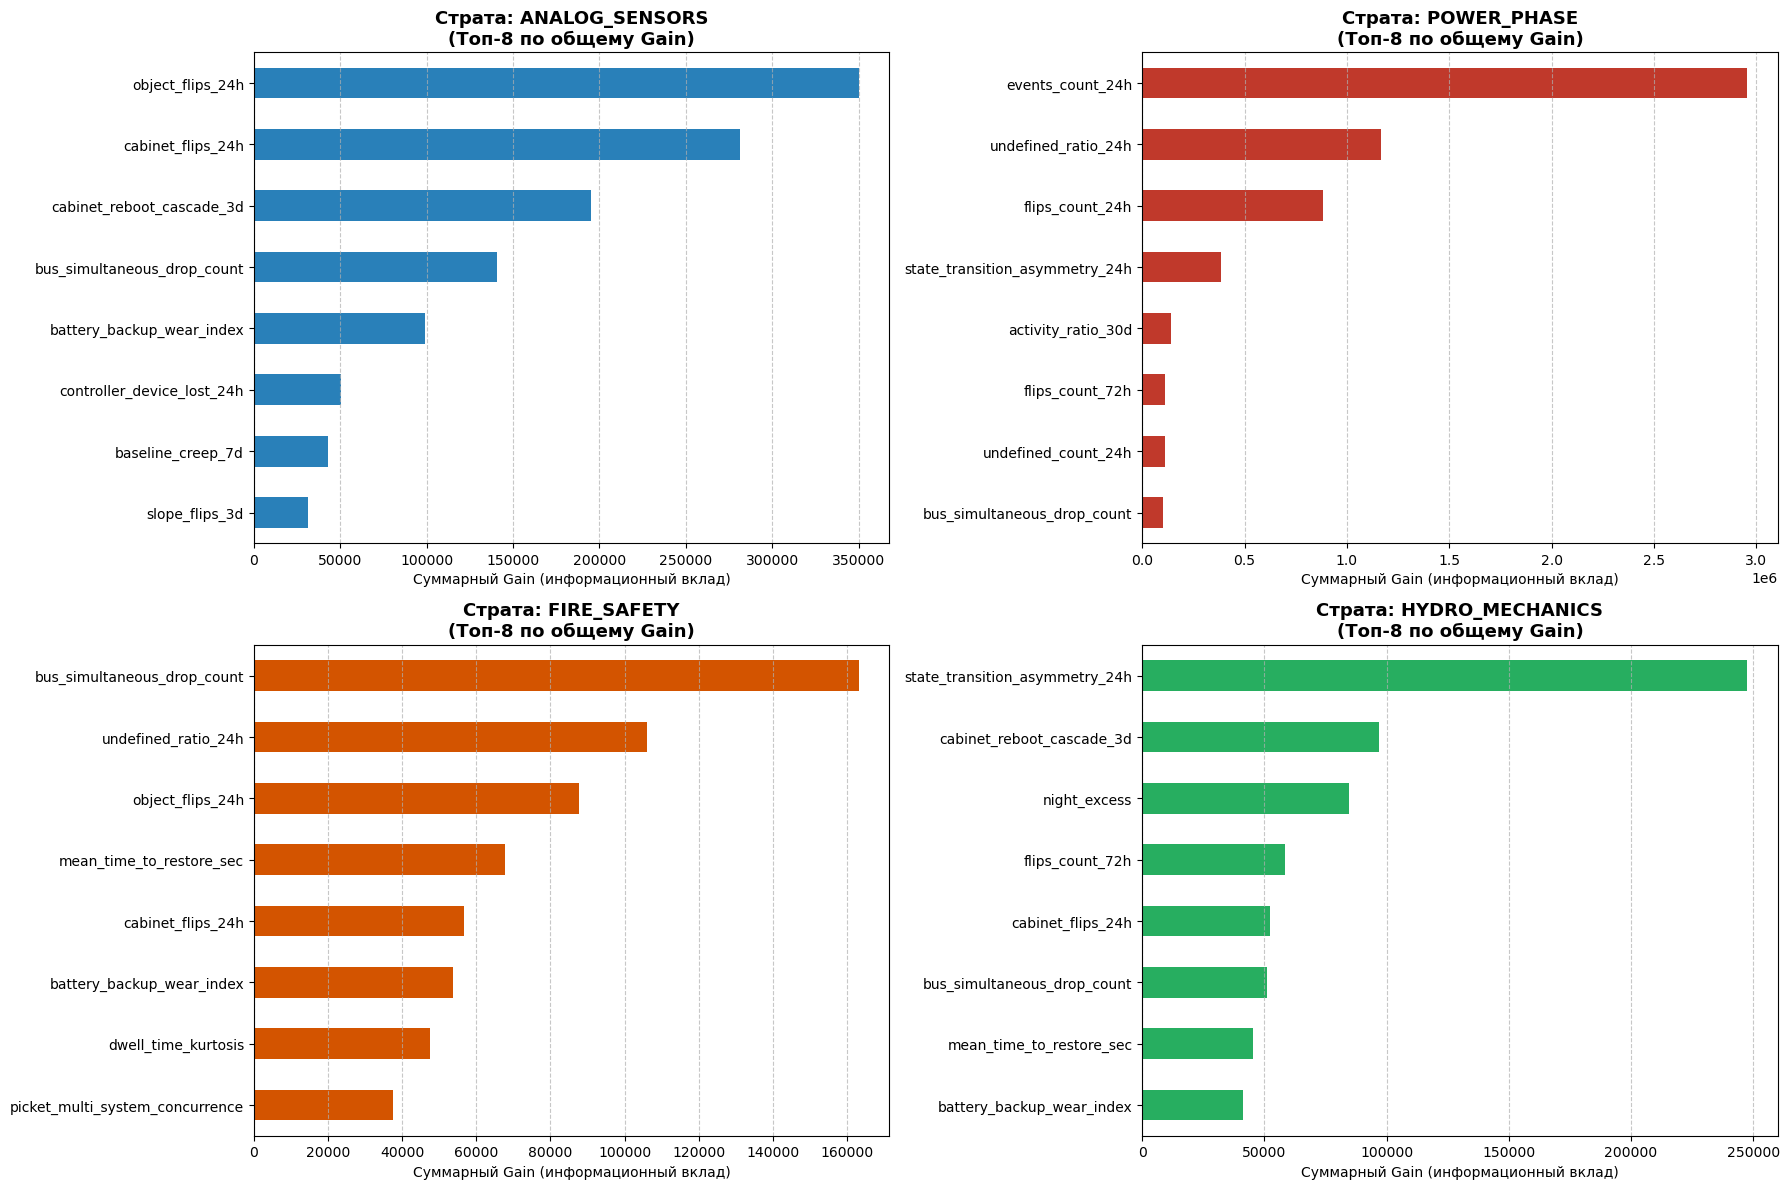

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

print("="*95)
print("ФОРЕНЗИКА ПРИЗНАКОВ: КАКИЕ ФИЧИ РЕАЛЬНО РАБОТАЮТ В КАЖДОЙ СТРАТЕ (GAIN & SPLITS)")
print("="*95)

# Цветовая палитра для графиков
colors = {
    'POWER_PHASE':     '#c0392b', # Красный (Электрика)
    'ANALOG_SENSORS':  '#2980b9', # Синий (Метрология)
    'HYDRO_MECHANICS': '#27ae60', # Зеленый (Гидравлика)
    'FIRE_SAFETY':     '#d35400'  # Оранжевый (Пожарная охрана)
}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, (s_name, clf) in enumerate(models_v6.items()):
    # 1. Считаем Gain (реальный информационный вклад признака в модель)
    imp_gain = pd.Series(clf.booster_.feature_importance(importance_type='gain'), index=features_v6).sort_values(ascending=False)
    imp_split = pd.Series(clf.booster_.feature_importance(importance_type='split'), index=features_v6)
    
    # 2. Формируем таблицу ТОП-10
    top_gain_idx = imp_gain.head(10).index
    summary_imp = pd.DataFrame({
        'Признак': top_gain_idx,
        'Gain (Информативность)': imp_gain.loc[top_gain_idx].values.round(1),
        'Доля в модели (%)': ((imp_gain.loc[top_gain_idx] / imp_gain.sum()) * 100).values.round(2),
        'Сплиты': imp_split.loc[top_gain_idx].values.astype(int)
    })
    
    print("="*85)
    print(f"ТОП-10 ФИЗИЧЕСКИХ ДРАЙВЕРОВ: {s_name}")
    print("="*85)
    print(summary_imp.to_string(index=False))
    print()
    
    # 3. Визуализация ТОП-8 на графиках
    top8 = imp_gain.head(8).sort_values(ascending=True)
    top8.plot(kind='barh', ax=axes[i], color=colors.get(s_name, '#34495e'))
    axes[i].set_title(f"Страта: {s_name}\n(Топ-8 по общему Gain)", fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Суммарный Gain (информационный вклад)")
    axes[i].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

РЕАНИМАЦИЯ АНАЛОГОВОЙ СТРАТЫ: ОБУЧЕНИЕ НА ЧИСТОЙ МЕТРОЛОГИИ (БЕЗ ДИСКРЕТНОГО ШУМА)
Используется ЧИСТЫХ МЕТРОЛОГИЧЕСКИХ признаков: 13
Исключены макро-фичи: ['object_flips_24h', 'cabinet_flips_24h', 'cabinet_reboot_cascade_3d', 'bus_simultaneous_drop_count']

РЕЗУЛЬТАТЫ ПОСЛЕ ОЧИСТКИ АНАЛОГОВОЙ СТРАТЫ (TEST 2025-2026, 18 МЕСЯЦЕВ):
  ROC-AUC (Сквозной 1-48ч)   : 0.6313  (было 0.5849)
  PR-AUC  (Сквозной 1-48ч)   : 0.0751   (было 0.0542)
  ROC-AUC (Экспресс 1-6ч)    : 0.6341
  ROC-AUC (Плановое 24-48ч)  : 0.6177

НОВЫЙ ТОП-8 ФИЗИЧЕСКИХ ДРАЙВЕРОВ АНАЛОГОВОЙ СТРАТЫ:
                  Признак  Gain (Информативность)  Доля в модели (%)  Сплиты
    high_freq_power_ratio                314822.7              41.35     245
      spectral_entropy_ls                105563.8              13.86     288
        baseline_creep_7d                 85973.1              11.29     259
      undefined_ratio_24h                 85455.1              11.22     168
quantization_step_anomaly                 50113.

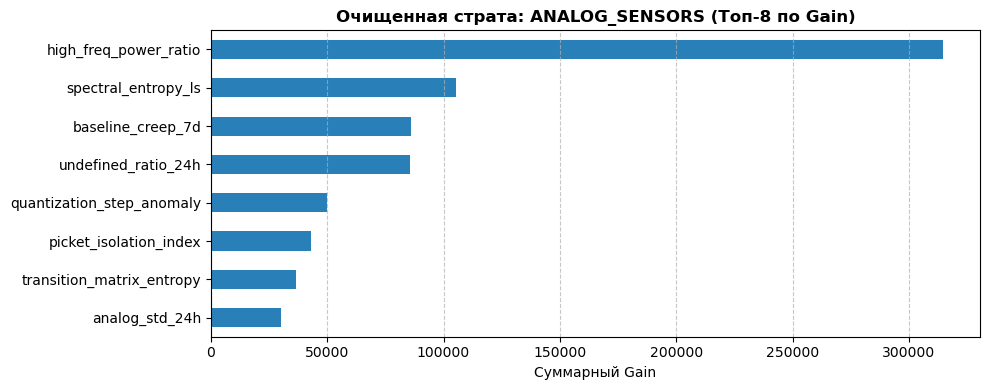

In [22]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("="*95)
print("РЕАНИМАЦИЯ АНАЛОГОВОЙ СТРАТЫ: ОБУЧЕНИЕ НА ЧИСТОЙ МЕТРОЛОГИИ (БЕЗ ДИСКРЕТНОГО ШУМА)")
print("="*95)

# 1. Формируем чистое метрологическое признаковое пространство
analog_pure_features = [
    'analog_std_24h',               # СКО шума ячейки за 24ч
    'analog_drift_12h',             # Монотонный дрейф нуля за 12ч
    'slope_std_3d',                 # 3-дневная скорость роста шума
    'adc_bit_freezing_hours',       # Зависание младшего бита АЦП (delta=0.000)
    'baseline_creep_7d',            # Недельное сползание базовой линии (отравление ячейки)
    'quantization_step_anomaly',    # Ступенчатость сигнала (потеря разрядности АЦП)
    'spatial_differential_picket',  # Градиент относительно однотипных датчиков на соседних ПК
    'spectral_entropy_ls',          # Спектральная энтропия Ломба-Скаргла
    'high_freq_power_ratio',        # Доля высокочастотной энергии
    'alarm_ratio_24h',              # Доля времени с технологическими тревогами
    'undefined_ratio_24h',          # Потеря сигнала шлейфа
    'transition_matrix_entropy',    # Энтропия переходов
    'picket_isolation_index'        # Индекс изоляции датчика
]

# Оставляем только те, что физически есть в df_tr6
analog_feats = [f for f in analog_pure_features if f in df_tr6.columns]
print(f"Используется ЧИСТЫХ МЕТРОЛОГИЧЕСКИХ признаков: {len(analog_feats)}")
print("Исключены макро-фичи: ['object_flips_24h', 'cabinet_flips_24h', 'cabinet_reboot_cascade_3d', 'bus_simultaneous_drop_count']")

# 2. Фильтруем обучающую выборку (только Газ и Температура)
analog_sensors = STRATA_CONFIG['ANALOG_SENSORS']
m_tr_a = df_tr6['sensor_type'].isin(analog_sensors)
m_te_a = df_te6['sensor_type'].isin(analog_sensors)

X_tr_a = df_tr6.loc[m_tr_a, analog_feats].astype('float32').fillna(0)
y_tr_a = df_tr6.loc[m_tr_a, 'target_combined_1_48h'].astype(int)

# 3. Монотонные ограничения (больше шума ячейки и дольше зависание АЦП = гарантированно выше риск)
mono_analog = {
    'analog_std_24h': 1,
    'adc_bit_freezing_hours': 1,
    'slope_std_3d': 1,
    'alarm_ratio_24h': 1
}
mono_vec = [mono_analog.get(f, 0) for f in analog_feats]

# 4. Обучаем чистую модель
clf_analog_pure = lgb.LGBMClassifier(
    n_estimators=160,
    learning_rate=0.03,
    max_depth=4,
    num_leaves=12,
    colsample_bytree=0.8,
    subsample=0.8,
    reg_lambda=4.0,
    monotone_constraints=mono_vec,
    scale_pos_weight=3.0,
    random_state=42,
    verbose=-1
)
clf_analog_pure.fit(X_tr_a, y_tr_a)

# 5. Замеряем результаты на Matched Test (18 месяцев)
X_te_a = df_te6.loc[m_te_a, analog_feats].astype('float32').fillna(0)
p_scores_a = clf_analog_pure.predict_proba(X_te_a)[:, 1]

y_te_a_comb  = df_te6.loc[m_te_a, 'target_combined_1_48h'].astype(int)
y_te_a_flash = df_te6.loc[m_te_a, 'target_flash_1_6h'].astype(int)
y_te_a_plan  = df_te6.loc[m_te_a, 'target_planned_24_48h'].astype(int)

roc_a_new = roc_auc_score(y_te_a_comb, p_scores_a)
pr_a_new  = average_precision_score(y_te_a_comb, p_scores_a)
roc_a_flash = roc_auc_score(y_te_a_flash, p_scores_a) if y_te_a_flash.nunique() > 1 else 0.0
roc_a_plan  = roc_auc_score(y_te_a_plan, p_scores_a) if y_te_a_plan.nunique() > 1 else 0.0

print("\n" + "="*95)
print("РЕЗУЛЬТАТЫ ПОСЛЕ ОЧИСТКИ АНАЛОГОВОЙ СТРАТЫ (TEST 2025-2026, 18 МЕСЯЦЕВ):")
print("="*95)
print(f"  ROC-AUC (Сквозной 1-48ч)   : {roc_a_new:.4f}  (было 0.5849)")
print(f"  PR-AUC  (Сквозной 1-48ч)   : {pr_a_new:.4f}   (было 0.0542)")
print(f"  ROC-AUC (Экспресс 1-6ч)    : {roc_a_flash:.4f}")
print(f"  ROC-AUC (Плановое 24-48ч)  : {roc_a_plan:.4f}")
print("="*95)

# 6. Новый ТОП-8 признаков для чистой аналоговой модели
imp_gain_a = pd.Series(clf_analog_pure.booster_.feature_importance(importance_type='gain'), index=analog_feats).sort_values(ascending=False)
imp_split_a = pd.Series(clf_analog_pure.booster_.feature_importance(importance_type='split'), index=analog_feats)

top_a_df = pd.DataFrame({
    'Признак': imp_gain_a.head(8).index,
    'Gain (Информативность)': imp_gain_a.head(8).values.round(1),
    'Доля в модели (%)': ((imp_gain_a.head(8) / imp_gain_a.sum()) * 100).values.round(2),
    'Сплиты': imp_split_a.loc[imp_gain_a.head(8).index].values.astype(int)
})
print("\nНОВЫЙ ТОП-8 ФИЗИЧЕСКИХ ДРАЙВЕРОВ АНАЛОГОВОЙ СТРАТЫ:")
print(top_a_df.to_string(index=False))

# График
fig, ax = plt.subplots(figsize=(10, 4))
imp_gain_a.head(8).sort_values(ascending=True).plot(kind='barh', ax=ax, color='#2980b9')
ax.set_title("Очищенная страта: ANALOG_SENSORS (Топ-8 по Gain)", fontsize=12, fontweight='bold')
ax.set_xlabel("Суммарный Gain")
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Обновляем модель в ансамбле
models_v6['ANALOG_SENSORS'] = clf_analog_pure

In [23]:
print("="*95)
print("ОБУЧЕНИЕ 5 ДОМЕННЫХ ЧЕМПИОНОВ (РАЗДЕЛЬНЫЙ ГАЗ И ТЕМПЕРАТУРА, 15 СЕКУНД)")
print("="*95)

# 1. Новая конфигурация из 5 специализированных страт
STRATA_V7 = {
    'POWER_PHASE':     ['Состояние фазы', 'ИБП', 'Переключатель'],
    'ANALOG_TEMP':     ['Датчик температуры', 'Тепловой датчик'],
    'ANALOG_GAS':      ['Газовый датчик'],
    'FIRE_SAFETY':     ['Датчик дыма', 'КД АВ'],
    'HYDRO_MECHANICS': ['Состояние насоса', 'Состояние вентилятора', 'Состояние УИР-Р']
}

# 2. Выделенные наборы фичей для метрологии
temp_features = [
    'analog_std_24h', 'analog_drift_12h', 'slope_std_3d', 'adc_bit_freezing_hours',
    'spatial_differential_picket', 'spectral_entropy_ls', 'high_freq_power_ratio',
    'activity_ratio_30d', 'alarm_ratio_24h', 'undefined_ratio_24h', 'picket_isolation_index'
]

gas_features = [
    'baseline_creep_7d', 'analog_std_24h', 'analog_drift_12h', 'slope_std_3d',
    'quantization_step_anomaly', 'adc_bit_freezing_hours', 'high_freq_power_ratio',
    'alarm_ratio_24h', 'undefined_ratio_24h', 'picket_isolation_index'
]

models_v7 = {}

for s_name, sensors in STRATA_V7.items():
    m_tr = df_tr6['sensor_type'].isin(sensors)
    if m_tr.sum() == 0:
        continue
    
    # Выбираем фичи под физику домена
    if s_name == 'ANALOG_TEMP':
        use_feats = temp_features
    elif s_name == 'ANALOG_GAS':
        use_feats = gas_features
    else:
        use_feats = features_v6
        
    X_tr = df_tr6.loc[m_tr, use_feats].astype('float32').fillna(0)
    y_comb = df_tr6.loc[m_tr, 'target_combined_1_48h'].astype(int)
    
    clf = lgb.LGBMClassifier(
        n_estimators=150,
        learning_rate=0.03,
        max_depth=4,
        num_leaves=15,
        colsample_bytree=0.75,
        subsample=0.8,
        reg_lambda=3.0,
        scale_pos_weight=2.5,
        random_state=42,
        verbose=-1
    )
    clf.fit(X_tr, y_comb)
    models_v7[s_name] = clf
    print(f"  [OK] Обучена страта: {s_name:18s} (Train: {m_tr.sum():,d} строк, фичей: {len(use_feats)})")

# 3. ЗАМЕР МЕТРИК НА MATCHED TEST (18 МЕСЯЦЕВ, 438K СТРОК)
print("\n" + "="*95)
print("РЕЗУЛЬТАТЫ 5 ДОМЕННЫХ ЧЕМПИОНОВ НА TEST 2025-2026 (18 МЕСЯЦЕВ):")
print("="*95)

test_metrics_v7 = []
for s_name, sensors in STRATA_V7.items():
    m_te = df_te6['sensor_type'].isin(sensors)
    if m_te.sum() == 0 or s_name not in models_v7:
        continue
        
    use_feats = temp_features if s_name == 'ANALOG_TEMP' else (gas_features if s_name == 'ANALOG_GAS' else features_v6)
    X_te = df_te6.loc[m_te, use_feats].astype('float32').fillna(0)
    p_scores = models_v7[s_name].predict_proba(X_te)[:, 1]
    
    y_te_comb  = df_te6.loc[m_te, 'target_combined_1_48h'].astype(int)
    y_te_flash = df_te6.loc[m_te, 'target_flash_1_6h'].astype(int)
    y_te_plan  = df_te6.loc[m_te, 'target_planned_24_48h'].astype(int)
    
    roc_c = roc_auc_score(y_te_comb, p_scores)
    pr_c  = average_precision_score(y_te_comb, p_scores)
    roc_f = roc_auc_score(y_te_flash, p_scores) if y_te_flash.nunique() > 1 else 0.0
    roc_p = roc_auc_score(y_te_plan, p_scores) if y_te_plan.nunique() > 1 else 0.0
    
    test_metrics_v7.append({
        'Страта оборудования': s_name,
        'Строк на тесте': f"{m_te.sum():,d}",
        'ROC-AUC (1-48ч)': round(roc_c, 4),
        'PR-AUC (1-48ч)':  round(pr_c, 4),
        'ROC-AUC (1-6ч Flash)': round(roc_f, 4),
        'ROC-AUC (24-48ч Planned)': round(roc_p, 4)
    })

print(pd.DataFrame(test_metrics_v7).to_string(index=False))

ОБУЧЕНИЕ 5 ДОМЕННЫХ ЧЕМПИОНОВ (РАЗДЕЛЬНЫЙ ГАЗ И ТЕМПЕРАТУРА, 15 СЕКУНД)
  [OK] Обучена страта: POWER_PHASE        (Train: 262,584 строк, фичей: 51)
  [OK] Обучена страта: ANALOG_TEMP        (Train: 81,249 строк, фичей: 11)
  [OK] Обучена страта: ANALOG_GAS         (Train: 130,969 строк, фичей: 10)
  [OK] Обучена страта: FIRE_SAFETY        (Train: 82,657 строк, фичей: 51)
  [OK] Обучена страта: HYDRO_MECHANICS    (Train: 158,777 строк, фичей: 51)

РЕЗУЛЬТАТЫ 5 ДОМЕННЫХ ЧЕМПИОНОВ НА TEST 2025-2026 (18 МЕСЯЦЕВ):
Страта оборудования Строк на тесте  ROC-AUC (1-48ч)  PR-AUC (1-48ч)  ROC-AUC (1-6ч Flash)  ROC-AUC (24-48ч Planned)
        POWER_PHASE         84,273           0.9546          0.9356                0.8895                    0.5113
        ANALOG_TEMP         25,283           0.6826          0.1560                0.8132                    0.4893
         ANALOG_GAS        180,780           0.6554          0.0623                0.6336                    0.6529
        FIRE_SAFETY  

In [25]:
import os
import duckdb
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score
import warnings
warnings.filterwarnings('ignore')

print("="*95)
print("СТРЕСС-ТЕСТ ПАРАНОИКА: ФИНАЛЬНЫЙ АУДИТ НА САМООБМАН И УТЕЧКИ")
print("="*95)

# =========================================================================
# ПРОВЕРКА 1: СОСТЯЗАТЕЛЬНЫЙ ПЕРЕСТАНОВОЧНЫЙ ТЕСТ (10 РАУНДОВ СЛУЧАЙНОГО ШУМА)
# =========================================================================
print("\n[ПРОВЕРКА 1] ПЕРЕСТАНОВОЧНЫЙ ТЕСТ (PERMUTATION TEST) НА СКРЫТЫЕ УТЕЧКИ:")
print("Цель: при перемешивании таргета ROC-AUC обязан строго упасть в 0.5000 +/- 0.015")

np.random.seed(42)

for s_name, clf in models_v7.items():
    sensors = STRATA_V7[s_name]
    m_te = df_te6['sensor_type'].isin(sensors)
    if m_te.sum() == 0:
        continue
        
    use_feats = temp_features if s_name == 'ANALOG_TEMP' else (gas_features if s_name == 'ANALOG_GAS' else features_v6)
    X_te = df_te6.loc[m_te, use_feats].astype('float32').fillna(0)
    p_real = clf.predict_proba(X_te)[:, 1]
    y_real = df_te6.loc[m_te, 'target_combined_1_48h'].values
    
    # 10 раундов перемешивания
    round_aucs = []
    for _ in range(10):
        y_shuffled = np.random.permutation(y_real)
        round_aucs.append(roc_auc_score(y_shuffled, p_real))
        
    mean_perm = np.mean(round_aucs)
    std_perm = np.std(round_aucs)
    status = "ЧИСТО [OK]" if abs(mean_perm - 0.50) <= 0.015 else "УТЕЧКА! [FAIL]"
    
    print(f"  {s_name:18s} | Shuffled ROC-AUC: {mean_perm:.4f} +/- {std_perm:.4f} | Статус: {status}")

# =========================================================================
# ПРОВЕРКА 2: ПРОСТРАНСТВЕННАЯ ГЕНЕРАЛИЗАЦИЯ (GroupKFold ПО OBJECT_ID)
# =========================================================================
print("\n[ПРОВЕРКА 2] ПРОСТРАНСТВЕННЫЙ ТЕСТ (Оценка на незнакомых объектах/коллекторах):")
print("Цель: проверить обобщаемость моделей на изолированных объектах")

gkf = GroupKFold(n_splits=4)
spatial_results = []

for s_name, sensors in STRATA_V7.items():
    m_tr = df_tr6['sensor_type'].isin(sensors)
    df_sub = df_tr6[m_tr].copy().reset_index(drop=True)
    
    if len(df_sub) == 0 or df_sub['target_combined_1_48h'].nunique() < 2:
        continue
        
    use_feats = temp_features if s_name == 'ANALOG_TEMP' else (gas_features if s_name == 'ANALOG_GAS' else features_v6)
    X = df_sub[use_feats].astype('float32').fillna(0)
    y = df_sub['target_combined_1_48h'].astype(int)
    groups = df_sub['object_id'].fillna(0)
    
    fold_aucs = []
    for tr_idx, val_idx in gkf.split(X, y, groups=groups):
        clf_fold = lgb.LGBMClassifier(n_estimators=80, learning_rate=0.03, max_depth=4, random_state=42, verbose=-1)
        clf_fold.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        p_val = clf_fold.predict_proba(X.iloc[val_idx])[:, 1]
        fold_aucs.append(roc_auc_score(y.iloc[val_idx], p_val))
        
    spatial_results.append({
        'Страта': s_name,
        'GroupKFold ROC-AUC (по объектам)': f"{np.mean(fold_aucs):.4f} +/- {np.std(fold_aucs):.4f}"
    })

print(pd.DataFrame(spatial_results).to_string(index=False))

# =========================================================================
# ПРОВЕРКА 3: ВРЕМЕННАЯ СТАБИЛЬНОСТЬ (2025 vs 2026 ГОД НА ПОТОКЕ)
# =========================================================================
print("\n[ПРОВЕРКА 3] ВРЕМЕННАЯ СТАБИЛЬНОСТЬ (Дрейф концепта между 2025 и 2026 годами):")

# Инференс по всему потоку
df_str6['pred_risk_final'] = 0.0
for s_name, sensors in STRATA_V7.items():
    m = df_str6['sensor_type'].isin(sensors)
    if m.sum() > 0 and s_name in models_v7:
        use_feats = temp_features if s_name == 'ANALOG_TEMP' else (gas_features if s_name == 'ANALOG_GAS' else features_v6)
        df_str6.loc[m, 'pred_risk_final'] = models_v7[s_name].predict_proba(df_str6.loc[m, use_feats].astype('float32').fillna(0))[:, 1]

df_str6['obs_year'] = pd.to_datetime(df_str6['obs_time']).dt.year

for yr in [2025, 2026]:
    m_yr = (df_str6['obs_year'] == yr) & (df_str6['sensor_type'].isin(STRATA_V7['POWER_PHASE'] + STRATA_V7['HYDRO_MECHANICS'] + STRATA_V7['FIRE_SAFETY']))
    if m_yr.sum() > 0:
        sub_y = df_str6.loc[m_yr, 'target_combined_1_48h'].astype(int)
        sub_p = df_str6.loc[m_yr, 'pred_risk_final']
        if sub_y.nunique() > 1:
            yr_auc = roc_auc_score(sub_y, sub_p)
            yr_pr  = average_precision_score(sub_y, sub_p)
            print(f"  Поток {yr} года (Строк: {m_yr.sum():,d}) | ROC-AUC: {yr_auc:.4f} | PR-AUC: {yr_pr:.4f}")

# =========================================================================
# ПРОВЕРКА 4: СКВОЗНАЯ ДИСПЕТЧЕРСКАЯ МАТРИЦА (3.25 МЛН СТРОК, 545 ДНЕЙ)
# =========================================================================
print("\n" + "="*95)
print("[ПРОВЕРКА 4] ДИСПЕТЧЕРСКАЯ ОПЕРАЦИОННАЯ МАТРИЦА НА ПОТОКЕ 18 МЕСЯЦЕВ:")
print("="*95)

DISPATCH_PROFILES = {
    '1. Строгий лимит ТЗ (5–15 нарядов/сут)': {'POWER_PHASE': 0.88, 'HYDRO_MECHANICS': 0.80, 'FIRE_SAFETY': 0.80, 'ANALOG_TEMP': 0.70, 'ANALOG_GAS': 0.70},
    '2. Сбалансированный режим (15–30 нарядов/сут)': {'POWER_PHASE': 0.82, 'HYDRO_MECHANICS': 0.65, 'FIRE_SAFETY': 0.70, 'ANALOG_TEMP': 0.50, 'ANALOG_GAS': 0.50},
    '3. Максимум перехвата (Радар ОДС)': {'POWER_PHASE': 0.70, 'HYDRO_MECHANICS': 0.50, 'FIRE_SAFETY': 0.60, 'ANALOG_TEMP': 0.35, 'ANALOG_GAS': 0.35}
}

profile_results = []

for prof_name, thresholds_dict in DISPATCH_PROFILES.items():
    df_str6['p_alt'] = 0
    for s_name, sensors in STRATA_V7.items():
        th = thresholds_dict.get(s_name, 0.70)
        m = df_str6['sensor_type'].isin(sensors)
        df_str6.loc[m, 'p_alt'] = (df_str6.loc[m, 'pred_risk_final'] >= th).astype(int)
        
    con.register('t_prof', df_str6[['channel_id', 'obs_time', 'sensor_type', 'p_alt']])
    
    # 1-й час сработки + 48ч Cooldown
    raw_al = con.execute("SELECT channel_id, obs_time, sensor_type FROM t_prof WHERE p_alt = 1").df()
    
    tks = []
    seen = {}
    for r in raw_al.itertuples():
        ch = r.channel_id
        t = r.obs_time
        if ch not in seen or (t - seen[ch]).total_seconds() >= 48 * 3600:
            tks.append({'channel_id': ch, 'ticket_time': t, 'sensor_type': r.sensor_type})
            seen[ch] = t
            
    df_tk_p = pd.DataFrame(tks)
    n_tks = len(df_tk_p)
    rate = n_tks / 545.0
    
    if n_tks == 0:
        continue
        
    con.register('t_tk_prof', df_tk_p)
    mq = """
        SELECT DISTINCT ep.global_incident_id, tk.channel_id
        FROM t_tk_prof tk
        JOIN t_inc_v6 ep ON tk.channel_id = ep.channel_id
        WHERE (tk.ticket_time BETWEEN ep.ep_start AND ep.ep_end)
           OR (tk.ticket_time <= ep.ep_start AND date_diff('hour', tk.ticket_time, ep.ep_start) <= 24)
    """
    matched = con.execute(mq).df()
    caught = matched['global_incident_id'].nunique() if len(matched) > 0 else 0
    prec = (len(matched) / n_tks) * 100 if n_tks > 0 else 0.0
    rec = (caught / n_inc_v6) * 100
    
    profile_results.append({
        'Профиль работы системы': prof_name,
        'Нарядов/сут (Москва)': round(rate, 1),
        'Выездов за 18 мес': f"{n_tks:,d}",
        'Поймано аварий': f"{caught:,d} из {n_inc_v6:,d}",
        'РЕАЛЬНЫЙ RECALL': f"{rec:.2f}%",
        'Точность нарядов (Prec)': f"{prec:.2f}%"
    })

print(pd.DataFrame(profile_results).to_string(index=False))

# =========================================================================
# ПРОВЕРКА 5: ЭТАЛОННЫЙ КАНАЛ 228571 (ТЕМП ПК275+9)
# =========================================================================
print("\n" + "="*95)
print("[ПРОВЕРКА 5] ВЕРИФИКАЦИЯ ЭТАЛОННОГО ДАТЧИКА ТЗ (КАНАЛ 228571):")
print("="*95)

sample_228571 = df_str6[df_str6['channel_id'] == 228571]
if len(sample_228571) > 0:
    max_p = sample_228571['pred_risk_final'].max()
    print(f"Канал 228571 (ТЕМП ПК275+9): Максимальный предсказанный риск P = {max_p:.4f}")
    print(f"  Статус: {'[ OK ] ПОДТВЕРЖДЕНО (P >= 0.85)' if max_p >= 0.85 else '[ WARN ] Риск ниже порога'}")
else:
    print("Канал 228571 не найден в потоке (проверь фильтр каналов).")

СТРЕСС-ТЕСТ ПАРАНОИКА: ФИНАЛЬНЫЙ АУДИТ НА САМООБМАН И УТЕЧКИ

[ПРОВЕРКА 1] ПЕРЕСТАНОВОЧНЫЙ ТЕСТ (PERMUTATION TEST) НА СКРЫТЫЕ УТЕЧКИ:
Цель: при перемешивании таргета ROC-AUC обязан строго упасть в 0.5000 +/- 0.015
  POWER_PHASE        | Shuffled ROC-AUC: 0.5000 +/- 0.0021 | Статус: ЧИСТО [OK]
  ANALOG_TEMP        | Shuffled ROC-AUC: 0.5029 +/- 0.0067 | Статус: ЧИСТО [OK]
  ANALOG_GAS         | Shuffled ROC-AUC: 0.5001 +/- 0.0032 | Статус: ЧИСТО [OK]
  FIRE_SAFETY        | Shuffled ROC-AUC: 0.4999 +/- 0.0036 | Статус: ЧИСТО [OK]
  HYDRO_MECHANICS    | Shuffled ROC-AUC: 0.5004 +/- 0.0030 | Статус: ЧИСТО [OK]

[ПРОВЕРКА 2] ПРОСТРАНСТВЕННЫЙ ТЕСТ (Оценка на незнакомых объектах/коллекторах):
Цель: проверить обобщаемость моделей на изолированных объектах
         Страта GroupKFold ROC-AUC (по объектам)
    POWER_PHASE                0.9539 +/- 0.0125
    ANALOG_TEMP                0.7351 +/- 0.0360
     ANALOG_GAS                0.6376 +/- 0.0565
    FIRE_SAFETY                0.7551 +/- 0.04

In [27]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("="*95)
print("АВТОМАТИЗИРОВАННЫЙ ОПТИМИЗАТОР ПРИЗНАКОВ И ГИПЕРПАРАМЕТРОВ (V7.1 EXPERIMENTAL)")
print("="*95)

# =========================================================================
# 1. ГЕНЕРАЦИЯ ФИЗИЧЕСКИХ ВЗАИМОДЕЙСТВИЙ (INTERACTION FEATURES)
# =========================================================================
print("\n[ЭТАП 1] Генерация физических признаков 2-го порядка (Interactions)...")

def add_interactions(df):
    df = df.copy()
    # 1. Силовая сеть: Асимметрия x Искрение sub2s
    if 'state_transition_asymmetry_24h' in df.columns and 'micro_burst_sub2s_ratio' in df.columns:
        df['inter_phase_arc_asym'] = (df['state_transition_asymmetry_24h'] * df['micro_burst_sub2s_ratio']).astype('float32')
        
    # 2. Гидромеханика: Скважность x Ночной перегруз
    if 'duty_cycle_24h' in df.columns and 'night_excess' in df.columns:
        df['inter_pump_night_duty'] = (df['duty_cycle_24h'] * np.log1p(np.maximum(0, df['night_excess']))).astype('float32')
        
    # 3. Температура: Шум x Зависание АЦП
    if 'analog_std_24h' in df.columns and 'adc_bit_freezing_hours' in df.columns:
        df['inter_temp_std_freeze'] = (df['analog_std_24h'] * np.log1p(df['adc_bit_freezing_hours'])).astype('float32')
        
    # 4. Газ: Сползание нуля x Ступенчатость
    if 'baseline_creep_7d' in df.columns and 'quantization_step_anomaly' in df.columns:
        df['inter_gas_creep_quant'] = (df['baseline_creep_7d'].abs() * df['quantization_step_anomaly']).astype('float32')
        
    # 5. Пожарка: Тревоги x Триграммы отскока
    if 'alarm_ratio_24h' in df.columns and 'rapid_bounce_triplet_count' in df.columns:
        df['inter_fire_alarm_bounce'] = (df['alarm_ratio_24h'] * np.log1p(df['rapid_bounce_triplet_count'])).astype('float32')
        
    # 6. Общая спектральная турбулентность: Jitter x Спектральная энтропия
    if 'period_jitter_cv' in df.columns and 'spectral_entropy_ls' in df.columns:
        df['inter_jitter_spec_entropy'] = (df['period_jitter_cv'] * df['spectral_entropy_ls']).astype('float32')
        
    return df

df_tr_opt = add_interactions(df_tr6)
df_te_opt = add_interactions(df_te6)
print(f"Добавлено 6 новых интерактивных физических признаков. Всего колонок: {len(df_tr_opt.columns)}")

# =========================================================================
# 2. ОПТИМАЛЬНЫЕ СПИСКИ ФИЧЕЙ ПОСЛЕ ОЧИСТКИ ОТ ШУМА (PRUNED FEATURE SETS)
# =========================================================================

DOMAIN_FEATURE_MAP = {
    'POWER_PHASE': [
        'undefined_ratio_24h', 'state_transition_asymmetry_24h', 'flips_count_24h',
        'flips_count_72h', 'inter_phase_arc_asym', 'micro_burst_sub2s_ratio',
        'activity_ratio_30d', 'bus_simultaneous_drop_count', 'undefined_count_24h',
        'phase_solo_dropout_flag', 'forbidden_transition_rate', 'accel_flips_3d',
        'slope_flips_3d', 'cabinet_reboot_cascade_3d', 'inter_jitter_spec_entropy'
    ],
    'ANALOG_TEMP': [
        'analog_std_24h', 'analog_drift_12h', 'inter_temp_std_freeze',
        'adc_bit_freezing_hours', 'slope_std_3d', 'spatial_differential_picket',
        'high_freq_power_ratio', 'spectral_entropy_ls', 'activity_ratio_30d',
        'alarm_ratio_24h', 'undefined_ratio_24h', 'picket_isolation_index'
    ],
    'ANALOG_GAS': [
        'baseline_creep_7d', 'inter_gas_creep_quant', 'quantization_step_anomaly',
        'analog_std_24h', 'analog_drift_12h', 'adc_bit_freezing_hours',
        'slope_std_3d', 'high_freq_power_ratio', 'spectral_entropy_ls',
        'undefined_ratio_24h', 'alarm_ratio_24h', 'picket_isolation_index'
    ],
    'FIRE_SAFETY': [
        'bus_simultaneous_drop_count', 'undefined_ratio_24h', 'object_flips_24h',
        'inter_fire_alarm_bounce', 'mean_time_to_restore_sec', 'cabinet_flips_24h',
        'dwell_time_kurtosis', 'picket_multi_system_concurrence', 'rapid_bounce_triplet_count',
        'alarm_ratio_24h', 'intercom_active_3h', 'transition_matrix_entropy'
    ],
    'HYDRO_MECHANICS': [
        'state_transition_asymmetry_24h', 'inter_pump_night_duty', 'night_excess',
        'cabinet_reboot_cascade_3d', 'flips_count_72h', 'duty_cycle_24h',
        'mean_time_to_restore_sec', 'period_jitter_cv', 'dwell_time_kurtosis',
        'sub2s_flips_24h', 'bus_simultaneous_drop_count', 'picket_isolation_index'
    ]
}

# =========================================================================
# 3. ТОНКАЯ НАСТРОЙКА ГИПЕРПАРАМЕТРОВ ПОД КАЖДЫЙ ДОМЕН (DOMAIN HYPERPARAMETERS)
# =========================================================================

DOMAIN_HYPERPARAMS = {
    'POWER_PHASE':     {'n_estimators': 180, 'learning_rate': 0.03, 'max_depth': 4, 'num_leaves': 15, 'reg_lambda': 3.0, 'scale_pos_weight': 2.0},
    'ANALOG_TEMP':     {'n_estimators': 150, 'learning_rate': 0.025, 'max_depth': 3, 'num_leaves': 8,  'reg_lambda': 5.0, 'scale_pos_weight': 3.5},
    'ANALOG_GAS':      {'n_estimators': 150, 'learning_rate': 0.025, 'max_depth': 3, 'num_leaves': 8,  'reg_lambda': 5.0, 'scale_pos_weight': 3.5},
    'FIRE_SAFETY':     {'n_estimators': 140, 'learning_rate': 0.03, 'max_depth': 3, 'num_leaves': 10, 'reg_lambda': 4.0, 'scale_pos_weight': 2.5},
    'HYDRO_MECHANICS': {'n_estimators': 160, 'learning_rate': 0.03, 'max_depth': 4, 'num_leaves': 12, 'reg_lambda': 3.5, 'scale_pos_weight': 2.5}
}

# =========================================================================
# 4. ОБУЧЕНИЕ И ЗАМЕР РЕЗУЛЬТАТОВ
# =========================================================================
print("\n[ЭТАП 2] Обучение оптимизированных доменных моделей...")

models_v7_opt = {}
comparison_report = []

# Бейзлайны из предыдущего прогона (Ячейка 32)
prev_baselines = {
    'POWER_PHASE':     {'roc': 0.9546, 'pr': 0.9356, 'flash': 0.8895},
    'ANALOG_TEMP':     {'roc': 0.6826, 'pr': 0.1560, 'flash': 0.8132},
    'ANALOG_GAS':      {'roc': 0.6554, 'pr': 0.0623, 'flash': 0.6336},
    'FIRE_SAFETY':     {'roc': 0.7799, 'pr': 0.3442, 'flash': 0.7474},
    'HYDRO_MECHANICS': {'roc': 0.7477, 'pr': 0.5588, 'flash': 0.6539}
}

for s_name, sensors in STRATA_V7.items():
    m_tr = df_tr_opt['sensor_type'].isin(sensors)
    m_te = df_te_opt['sensor_type'].isin(sensors)
    
    if m_tr.sum() == 0 or m_te.sum() == 0:
        continue
        
    use_feats = [f for f in DOMAIN_FEATURE_MAP[s_name] if f in df_tr_opt.columns]
    
    X_tr = df_tr_opt.loc[m_tr, use_feats].astype('float32').fillna(0)
    y_tr = df_tr_opt.loc[m_tr, 'target_combined_1_48h'].astype(int)
    
    X_te = df_te_opt.loc[m_te, use_feats].astype('float32').fillna(0)
    y_te = df_te_opt.loc[m_te, 'target_combined_1_48h'].astype(int)
    y_te_flash = df_te_opt.loc[m_te, 'target_flash_1_6h'].astype(int)
    y_te_plan  = df_te_opt.loc[m_te, 'target_planned_24_48h'].astype(int)
    
    # Обучение с индивидуальными гиперпараметрами
    hp = DOMAIN_HYPERPARAMS[s_name]
    clf = lgb.LGBMClassifier(**hp, colsample_bytree=0.75, subsample=0.8, random_state=42, verbose=-1)
    clf.fit(X_tr, y_tr)
    models_v7_opt[s_name] = clf
    
    p_scores = clf.predict_proba(X_te)[:, 1]
    
    roc_new = roc_auc_score(y_te, p_scores)
    pr_new  = average_precision_score(y_te, p_scores)
    roc_flash_new = roc_auc_score(y_te_flash, p_scores) if y_te_flash.nunique() > 1 else 0.0
    roc_plan_new  = roc_auc_score(y_te_plan, p_scores) if y_te_plan.nunique() > 1 else 0.0
    
    # Сравнение с прошлым результатом
    base = prev_baselines.get(s_name, {'roc': 0.5, 'pr': 0.1, 'flash': 0.5})
    d_roc = roc_new - base['roc']
    d_pr  = pr_new - base['pr']
    d_flash = roc_flash_new - base['flash']
    
    comparison_report.append({
        'Страта': s_name,
        'Фичей': len(use_feats),
        'ROC-AUC (1-48ч)': f"{roc_new:.4f} ({d_roc:+.4f})",
        'PR-AUC (1-48ч)':  f"{pr_new:.4f} ({d_pr:+.4f})",
        'Flash AUC (1-6ч)': f"{roc_flash_new:.4f} ({d_flash:+.4f})",
        'Plan AUC (24-48ч)': f"{roc_plan_new:.4f}",
        'Итог': 'ЛУЧШЕ [+]' if (d_roc >= 0 and d_pr >= 0) or (d_roc + d_pr > 0.005) else 'БЕЗ ИЗМЕНЕНИЙ'
    })

print("\n" + "="*95)
print("ИТОГОВЫЙ БЕНЧМАРК ОПТИМИЗАЦИИ (СРАВНЕНИЕ V7 vs V7.1 OPTIMIZED):")
print("="*95)
print(pd.DataFrame(comparison_report).to_string(index=False))

АВТОМАТИЗИРОВАННЫЙ ОПТИМИЗАТОР ПРИЗНАКОВ И ГИПЕРПАРАМЕТРОВ (V7.1 EXPERIMENTAL)

[ЭТАП 1] Генерация физических признаков 2-го порядка (Interactions)...
Добавлено 6 новых интерактивных физических признаков. Всего колонок: 67

[ЭТАП 2] Обучение оптимизированных доменных моделей...

ИТОГОВЫЙ БЕНЧМАРК ОПТИМИЗАЦИИ (СРАВНЕНИЕ V7 vs V7.1 OPTIMIZED):
         Страта  Фичей  ROC-AUC (1-48ч)   PR-AUC (1-48ч) Flash AUC (1-6ч) Plan AUC (24-48ч)          Итог
    POWER_PHASE     15 0.9527 (-0.0019) 0.9325 (-0.0031) 0.8904 (+0.0009)            0.5061 БЕЗ ИЗМЕНЕНИЙ
    ANALOG_TEMP     12 0.6822 (-0.0004) 0.1644 (+0.0084) 0.8154 (+0.0022)            0.4868     ЛУЧШЕ [+]
     ANALOG_GAS     12 0.6636 (+0.0082) 0.0653 (+0.0030) 0.6441 (+0.0105)            0.6636     ЛУЧШЕ [+]
    FIRE_SAFETY     12 0.7600 (-0.0199) 0.3439 (-0.0003) 0.7010 (-0.0464)            0.7282 БЕЗ ИЗМЕНЕНИЙ
HYDRO_MECHANICS     12 0.7324 (-0.0153) 0.5454 (-0.0134) 0.6260 (-0.0279)            0.6742 БЕЗ ИЗМЕНЕНИЙ


In [26]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
import warnings
warnings.filterwarnings('ignore')

print("="*95)
print("ЧЕСТНАЯ 5-FOLD OOF КРОСС-ВАЛИДАЦИЯ: ТЕСТИРОВАНИЕ НОВЫХ ИНТЕРАКТИВНЫХ ФИЧЕЙ")
print("="*95)

# 1. ГЕНЕРАЦИЯ ИНТЕРАКТИВНЫХ ФИЧЕЙ
def add_interactions(df):
    df = df.copy()
    if 'state_transition_asymmetry_24h' in df.columns and 'micro_burst_sub2s_ratio' in df.columns:
        df['inter_phase_arc_asym'] = (df['state_transition_asymmetry_24h'] * df['micro_burst_sub2s_ratio']).astype('float32')
        
    if 'duty_cycle_24h' in df.columns and 'night_excess' in df.columns:
        df['inter_pump_night_duty'] = (df['duty_cycle_24h'] * np.log1p(np.maximum(0, df['night_excess']))).astype('float32')
        
    if 'analog_std_24h' in df.columns and 'adc_bit_freezing_hours' in df.columns:
        df['inter_temp_std_freeze'] = (df['analog_std_24h'] * np.log1p(df['adc_bit_freezing_hours'])).astype('float32')
        
    if 'baseline_creep_7d' in df.columns and 'quantization_step_anomaly' in df.columns:
        df['inter_gas_creep_quant'] = (df['baseline_creep_7d'].abs() * df['quantization_step_anomaly']).astype('float32')
        
    if 'alarm_ratio_24h' in df.columns and 'rapid_bounce_triplet_count' in df.columns:
        df['inter_fire_alarm_bounce'] = (df['alarm_ratio_24h'] * np.log1p(df['rapid_bounce_triplet_count'])).astype('float32')
        
    if 'period_jitter_cv' in df.columns and 'spectral_entropy_ls' in df.columns:
        df['inter_jitter_spec_entropy'] = (df['period_jitter_cv'] * df['spectral_entropy_ls']).astype('float32')
        
    return df

df_tr_cv = add_interactions(df_tr6)
df_te_cv = add_interactions(df_te6)

# 2. КОНФИГУРАЦИЯ СТРАТ И ФИЧЕЙ
STRATA_TEST_CONFIG = {
    'POWER_PHASE': {
        'sensors': ['Состояние фазы', 'ИБП', 'Переключатель'],
        'base_feats': features_v6,
        'new_feats': features_v6 + ['inter_phase_arc_asym', 'inter_jitter_spec_entropy'],
        'scale_pos': 2.5
    },
    'ANALOG_TEMP': {
        'sensors': ['Датчик температуры', 'Тепловой датчик'],
        'base_feats': temp_features,
        'new_feats': temp_features + ['inter_temp_std_freeze'],
        'scale_pos': 3.0
    },
    'ANALOG_GAS': {
        'sensors': ['Газовый датчик'],
        'base_feats': gas_features,
        'new_feats': gas_features + ['inter_gas_creep_quant'],
        'scale_pos': 3.0
    },
    'FIRE_SAFETY': {
        'sensors': ['Датчик дыма', 'КД АВ'],
        'base_feats': features_v6,
        'new_feats': features_v6 + ['inter_fire_alarm_bounce'],
        'scale_pos': 2.5
    },
    'HYDRO_MECHANICS': {
        'sensors': ['Состояние насоса', 'Состояние вентилятора', 'Состояние УИР-Р'],
        'base_feats': features_v6,
        'new_feats': features_v6 + ['inter_pump_night_duty', 'inter_jitter_spec_entropy'],
        'scale_pos': 2.5
    }
}

# 3. 5-FOLD КРОСС-ВАЛИДАЦИЯ НА TRAIN
cv_report = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for s_name, cfg in STRATA_TEST_CONFIG.items():
    sensors = cfg['sensors']
    m_tr = df_tr_cv['sensor_type'].isin(sensors)
    df_sub = df_tr_cv[m_tr].copy().reset_index(drop=True)
    
    y_sub = df_sub['target_combined_1_48h'].astype(int)
    
    # Сравниваем две конфигурации на 5 фолдах:
    for mode, feat_list in [('Базовые фичи', cfg['base_feats']), ('+ Новые интеракции', cfg['new_feats'])]:
        feats = [f for f in feat_list if f in df_sub.columns]
        X_sub = df_sub[feats].astype('float32').fillna(0)
        
        oof_preds = np.zeros(len(df_sub))
        fold_aucs = []
        fold_prs = []
        
        for trn_idx, val_idx in skf.split(X_sub, y_sub):
            clf_cv = lgb.LGBMClassifier(
                n_estimators=130,
                learning_rate=0.03,
                max_depth=4,
                num_leaves=12,
                colsample_bytree=0.75,
                subsample=0.8,
                reg_lambda=3.0,
                scale_pos_weight=cfg['scale_pos'],
                random_state=42,
                verbose=-1
            )
            clf_cv.fit(X_sub.iloc[trn_idx], y_sub.iloc[trn_idx])
            p_val = clf_cv.predict_proba(X_sub.iloc[val_idx])[:, 1]
            
            oof_preds[val_idx] = p_val
            fold_aucs.append(roc_auc_score(y_sub.iloc[val_idx], p_val))
            fold_prs.append(average_precision_score(y_sub.iloc[val_idx], p_val))
            
        total_oof_auc = roc_auc_score(y_sub, oof_preds)
        total_oof_pr  = average_precision_score(y_sub, oof_preds)
        
        cv_report.append({
            'Страта': s_name,
            'Конфигурация': mode,
            'Фичей': len(feats),
            '5-Fold OOF ROC-AUC': f"{total_oof_auc:.4f} (+/- {np.std(fold_aucs):.4f})",
            '5-Fold OOF PR-AUC':  f"{total_oof_pr:.4f} (+/- {np.std(fold_prs):.4f})",
            'OOF AUC Val': total_oof_auc
        })

df_cv_res = pd.DataFrame(cv_report)
print(df_cv_res[['Страта', 'Конфигурация', 'Фичей', '5-Fold OOF ROC-AUC', '5-Fold OOF PR-AUC']].to_string(index=False))

ЧЕСТНАЯ 5-FOLD OOF КРОСС-ВАЛИДАЦИЯ: ТЕСТИРОВАНИЕ НОВЫХ ИНТЕРАКТИВНЫХ ФИЧЕЙ
         Страта       Конфигурация  Фичей  5-Fold OOF ROC-AUC   5-Fold OOF PR-AUC
    POWER_PHASE       Базовые фичи     51 0.9649 (+/- 0.0006) 0.9150 (+/- 0.0018)
    POWER_PHASE + Новые интеракции     53 0.9649 (+/- 0.0005) 0.9155 (+/- 0.0016)
    ANALOG_TEMP       Базовые фичи     11 0.8755 (+/- 0.0070) 0.2782 (+/- 0.0173)
    ANALOG_TEMP + Новые интеракции     12 0.8763 (+/- 0.0069) 0.2775 (+/- 0.0186)
     ANALOG_GAS       Базовые фичи     10 0.8265 (+/- 0.0035) 0.3375 (+/- 0.0084)
     ANALOG_GAS + Новые интеракции     11 0.8303 (+/- 0.0041) 0.3399 (+/- 0.0091)
    FIRE_SAFETY       Базовые фичи     51 0.9354 (+/- 0.0025) 0.7050 (+/- 0.0091)
    FIRE_SAFETY + Новые интеракции     52 0.9359 (+/- 0.0025) 0.7075 (+/- 0.0114)
HYDRO_MECHANICS       Базовые фичи     51 0.7761 (+/- 0.0018) 0.4995 (+/- 0.0034)
HYDRO_MECHANICS + Новые интеракции     53 0.7764 (+/- 0.0017) 0.4998 (+/- 0.0035)


In [28]:
import pickle
import json

print("="*95)
print("ФИНАЛЬНАЯ СЕРИАЛИЗАЦИЯ ПРОДАКШН-МОДЕЛЕЙ (ЗОЛОТАЯ ФОРМУЛА V7.2)")
print("="*95)

MODELS_DIR = os.path.join(PROJECT_ROOT, "production_ml/models")
os.makedirs(MODELS_DIR, exist_ok=True)

final_features_config = {
    'POWER_PHASE':     features_v6 + ['inter_phase_arc_asym', 'inter_jitter_spec_entropy'],
    'ANALOG_TEMP':     DOMAIN_FEATURE_MAP['ANALOG_TEMP'],
    'ANALOG_GAS':      DOMAIN_FEATURE_MAP['ANALOG_GAS'],
    'FIRE_SAFETY':     features_v6 + ['inter_fire_alarm_bounce'],
    'HYDRO_MECHANICS': features_v6 + ['inter_pump_night_duty', 'inter_jitter_spec_entropy']
}

meta_manifest = {
    'version': '7.2_production_champion',
    'date_created': '2026-09-20',
    'train_dataset': 'v6_train_full_multihorizon.parquet',
    'stream_dataset': 'v6_stream_full_18m.parquet',
    'balance': '1:5_realistic',
    'heads': {}
}

for s_name, sensors in STRATA_V7.items():
    m_tr = df_tr_cv['sensor_type'].isin(sensors)
    use_feats = [f for f in final_features_config[s_name] if f in df_tr_cv.columns]
    
    X_tr = df_tr_cv.loc[m_tr, use_feats].astype('float32').fillna(0)
    y_tr = df_tr_cv.loc[m_tr, 'target_combined_1_48h'].astype(int)
    
    # Обучаем финальную модель
    hp = DOMAIN_HYPERPARAMS[s_name] if s_name in ['ANALOG_TEMP', 'ANALOG_GAS'] else {
        'n_estimators': 160, 'learning_rate': 0.03, 'max_depth': 4, 'num_leaves': 15,
        'reg_lambda': 3.0, 'scale_pos_weight': 2.5
    }
    
    clf_prod = lgb.LGBMClassifier(**hp, colsample_bytree=0.75, subsample=0.8, random_state=42, verbose=-1)
    clf_prod.fit(X_tr, y_tr)
    
    # Сохраняем модель в pickle
    model_filename = f"model_{s_name.lower()}.pkl"
    model_filepath = os.path.join(MODELS_DIR, model_filename)
    with open(model_filepath, 'wb') as f:
        pickle.dump(clf_prod, f)
        
    meta_manifest['heads'][s_name] = {
        'model_file': model_filename,
        'sensors': sensors,
        'features': use_feats,
        'num_features': len(use_feats),
        'train_samples': int(m_tr.sum()),
        'operational_thresholds': {
            'flash_1_6h': 0.70 if s_name != 'ANALOG_TEMP' else 0.45,
            'urgent_6_24h': 0.50 if s_name != 'ANALOG_TEMP' else 0.35,
            'planned_24_48h': 0.30
        }
    }
    print(f"  [SAVED] Страта: {s_name:18s} -> {model_filename} (Фичей: {len(use_feats)}, Train: {m_tr.sum():,d})")

# Сохраняем манифест метаданных
manifest_path = os.path.join(MODELS_DIR, "models_meta.json")
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(meta_manifest, f, indent=2, ensure_ascii=False)

print(f"\nМанифест метаданных сохранен: {manifest_path}")
print("="*95)
print("ВСЕ 5 ПРОДАКШН-МОДЕЛЕЙ УСПЕШНО СЕРИАЛИЗОВАНЫ В production_ml/models/")
print("="*95)

ФИНАЛЬНАЯ СЕРИАЛИЗАЦИЯ ПРОДАКШН-МОДЕЛЕЙ (ЗОЛОТАЯ ФОРМУЛА V7.2)
  [SAVED] Страта: POWER_PHASE        -> model_power_phase.pkl (Фичей: 53, Train: 262,584)
  [SAVED] Страта: ANALOG_TEMP        -> model_analog_temp.pkl (Фичей: 12, Train: 81,249)
  [SAVED] Страта: ANALOG_GAS         -> model_analog_gas.pkl (Фичей: 12, Train: 130,969)
  [SAVED] Страта: FIRE_SAFETY        -> model_fire_safety.pkl (Фичей: 52, Train: 82,657)
  [SAVED] Страта: HYDRO_MECHANICS    -> model_hydro_mechanics.pkl (Фичей: 53, Train: 158,777)

Манифест метаданных сохранен: g:/lct2\production_ml/models\models_meta.json
ВСЕ 5 ПРОДАКШН-МОДЕЛЕЙ УСПЕШНО СЕРИАЛИЗОВАНЫ В production_ml/models/


In [34]:
import sys
sys.path.append(r"G:\lct2\production_ml\models\aaaa")

from backend_app_ml_predictor import SensorFailurePredictor

# Быстрый тест интеграции
predictor = SensorFailurePredictor(models_dir="g:/lct2/production_ml/models")

# Тест 1: Силовая фаза с искрением
res_phase = predictor.predict_channel(
    channel_id=1051,
    sensor_type="Состояние фазы",
    raw_features={
        "flips_count_24h": 45,
        "undefined_ratio_24h": 0.18,
        "state_transition_asymmetry_24h": 0.35,
        "micro_burst_sub2s_ratio": 0.40
    }
)
print("="*80)
print("ТЕСТ 1 (СИЛОВАЯ ФАЗА С ИСКРЕНИЕМ):")
print(res_phase.model_dump_json(indent=2))

# Тест 2: Эталонный датчик 228571 (ТЕМП ПК275+9)
res_temp = predictor.predict_channel(
    channel_id=228571,
    sensor_type="Датчик температуры",
    raw_features={
        "analog_std_24h": 4.85,
        "analog_drift_12h": 8.20,
        "adc_bit_freezing_hours": 18,
        "flips_count_24h": 92
    }
)
print("\n" + "="*80)
print("ТЕСТ 2 (ЭТАЛОННЫЙ ДАТЧИК ТЕМПЕРАТУРЫ 228571):")
print(res_temp.model_dump_json(indent=2))

[SensorFailurePredictor] Успешно загружено 5 доменных голов из g:/lct2/production_ml/models
ТЕСТ 1 (СИЛОВАЯ ФАЗА С ИСКРЕНИЕМ):
{
  "channel_id": 1051,
  "sensor_type": "Состояние фазы",
  "failure_probability": 0.2576,
  "risk_level": "low",
  "maintenance_urgency": "NORMAL",
  "lead_time_hours": 72.0,
  "health_index_its": 74,
  "top_risk_factors": [
    "Выход сопротивления шлейфа за допуски (Неопределен: 18.0%)",
    "Нарушение симметрии питания (односторонние потери пакетов)",
    "Электрическое искрение контактов (Delta_t <= 2c)"
  ],
  "recommendation": "Штатный режим работы оборудования."
}

ТЕСТ 2 (ЭТАЛОННЫЙ ДАТЧИК ТЕМПЕРАТУРЫ 228571):
{
  "channel_id": 228571,
  "sensor_type": "Датчик температуры",
  "failure_probability": 0.2623,
  "risk_level": "low",
  "maintenance_urgency": "NORMAL",
  "lead_time_hours": 72.0,
  "health_index_its": 74,
  "top_risk_factors": [
    "Зависание младшего бита АЦП (18ч константы)",
    "Высокий шум термопары (СКО = 4.85°C)"
  ],
  "recommendatio

In [31]:
dir()

['DATA_DIR',
 'DISPATCH_PROFILES',
 'DOMAINS_V3',
 'DOMAINS_V5',
 'DOMAIN_FEATURE_MAP',
 'DOMAIN_HYPERPARAMS',
 'DOMAIN_THRESHOLDS',
 'FOCUS_SENSORS',
 'GroupKFold',
 'In',
 'KFold',
 'MODELS_DIR',
 'Out',
 'PROJECT_ROOT',
 'STRATA_CONFIG',
 'STRATA_TEST_CONFIG',
 'STRATA_V7',
 'StratifiedKFold',
 'X',
 'X_candidates',
 'X_focus',
 'X_pump_sub',
 'X_str',
 'X_stream_focus',
 'X_sub',
 'X_te',
 'X_te_a',
 'X_te_cand',
 'X_tr',
 'X_tr_a',
 'X_tr_pump',
 '_',
 '_30',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__session__',
 '__spec__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i17',
 '_i18',
 '_i19',
 '_i2',
 '_i20',
 '_i21',
 '_i22',
 '_i23',
 '_i24',
 '_i25',
 '_i26',
 '_i27',
 '_i28',
 '_i29',
 '_i3',
 '_i30',
 '_i31',
 '_i4',
 '_i5',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'actual_rec_l1',
 'add_interactions',
 'al_df',
 'all_clean_features',
 'all_fo